# 🔬 SOLUCIÓN DEFINITIVA: Convolutional Autoencoder con Coherencia Espacial

## Estrategia: Aprender Patrones Espaciales con CNNs

**Problema identificado en 03b**: Los Dense Autoencoders procesan cada píxel aisladamente, sin capturar vecindad geográfica → Moran's I ≈ 0

**Solución**: Convolutional Autoencoder inspirado en `cr2_cnn.ipynb`

### Arquitectura propuesta

**Organización de datos**: `(n_scenarios, lat, lon, features_climáticas)`
- Cada muestra = 1 escenario completo con estructura espacial 2D
- Las convoluciones procesan ventanas espaciales (vecindad geográfica)
- Los embeddings capturan patrones espaciales de manera natural

**Encoder**: Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense(latent)

**Decoder**: Dense → Reshape → Conv2DTranspose → UpSampling → Conv2DTranspose

**Multimodelo**: 3 arquitecturas con diferentes profundidades
- Model_A: 2 capas conv (baseline)
- Model_B: 3 capas conv (optimal)
- Model_C: 4 capas conv (extended)

### Ventajas esperadas

✅ **Captura explícita de vecindad**: Las convoluciones procesan kernels 3×3 o 5×5  
✅ **Invarianza a traslación**: Patrones espaciales detectados en cualquier ubicación  
✅ **Reducción progresiva**: MaxPooling preserva características espaciales dominantes  
✅ **Coherencia natural**: Los embeddings reflejan zonificación geográfica  
✅ **Moran's I > 0.3 esperado**: Similar a cr2_cnn.ipynb

### Workflow

1. Cargar datos y metadata (MASK, grid_shape, coordenadas)
2. Reorganizar de `(píxeles, features)` → `(escenarios, lat, lon, features)`
3. Rellenar píxeles inválidos con 0 (o media) donde MASK=False
4. Construir 3 Convolutional Autoencoders con diferentes profundidades
5. Entrenar cada modelo con todos los escenarios
6. Extraer embeddings por escenario
7. Concatenar embeddings de los 3 modelos (multimodel ensemble)
8. Aplicar K-means sobre embeddings concatenados por píxel
9. Calcular índice de resiliencia basado en distancia al centroide
10. **Validar Moran's I** (objetivo: > 0.3)

## Paso 1: Imports y configuración

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from datetime import datetime

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LeakyReLU, Dropout, Flatten, Reshape,
    Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Spatial
from scipy.spatial.distance import cdist

# Config
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
tf.random.set_seed(42)

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU disponible: {gpus[0].name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"⚠️  Error configurando GPU: {e}")
else:
    print("⚠️  Ejecutando en CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

✅ GPU disponible: /physical_device:GPU:0
TensorFlow version: 2.19.0
NumPy version: 1.26.4


In [10]:
# Configuración de rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
TENSORS_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'
RESULTS_DIR = BASE_DIR / 'data' / 'autoencoder_results'
MODEL_DIR = BASE_DIR / 'data' / 'autoencoder_trained' / 'conv_multimodel'
PLOTS_DIR = BASE_DIR / 'plots' / 'autoencoder_conv'

# Crear directorios
MODEL_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Configuración multimodelo convolucional (OPTIMIZADO para GPU)
MODELS_CONFIG = {
    'Conv_A': {
        'n_conv_layers': 2,
        'filters': [16, 32],  # Reducido: menos filtros = menos memoria
        'latent_dim': 32,  # Reducido
        'description': 'Baseline 2 Conv layers (optimizado)'
    },
    'Conv_B': {
        'n_conv_layers': 2,  # Reducido de 3 a 2 capas
        'filters': [32, 64],  # Reducido
        'latent_dim': 64,  # Reducido
        'description': 'Optimal 2 Conv layers (optimizado)'
    },
    'Conv_C': {
        'n_conv_layers': 3,  # Reducido de 4 a 3 capas
        'filters': [32, 64, 128],  # Reducido
        'latent_dim': 128,  # Reducido
        'description': 'Extended 3 Conv layers (optimizado)'
    }
}

# Parámetros de entrenamiento
TRAIN_CONFIG = {
    'batch_size': 3,  # Batch size = número de samples (procesamos los 3 escenarios juntos)
    'epochs': 200,  # Reducido para evitar overfitting con solo 3 samples
    'learning_rate': 1e-3,  # Aumentado para convergencia más rápida
    'patience': 30,  # Reducido
    'min_delta': 1e-4,
    'validation_split': 0.0,  # No split, usaremos los 3 escenarios para entrenar
    'seed': 42,
    'verbose': 2  # Verbose=2 muestra solo 1 línea por epoch (menos output)
}

MODE = 'test'
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']

print("="*80)
print("CONVOLUTIONAL MULTIMODELO PARA COHERENCIA ESPACIAL")
print("="*80)
print(f"\n📁 Directorios:")
print(f"   Tensores: {TENSORS_DIR}")
print(f"   Modelos: {MODEL_DIR}")
print(f"   Plots: {PLOTS_DIR}")
print(f"\n🧠 Modelos CNN a entrenar:")
for name, config in MODELS_CONFIG.items():
    print(f"   - {name}: {config['description']}")
    print(f"     Filters: {config['filters']}, Latent: {config['latent_dim']}")
print(f"\n⚙️  Configuración de entrenamiento:")
for key, val in TRAIN_CONFIG.items():
    print(f"   {key}: {val}")
print("="*80)

CONVOLUTIONAL MULTIMODELO PARA COHERENCIA ESPACIAL

📁 Directorios:
   Tensores: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors
   Modelos: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained/conv_multimodel
   Plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv

🧠 Modelos CNN a entrenar:
   - Conv_A: Baseline 2 Conv layers (optimizado)
     Filters: [16, 32], Latent: 32
   - Conv_B: Optimal 2 Conv layers (optimizado)
     Filters: [32, 64], Latent: 64
   - Conv_C: Extended 3 Conv layers (optimizado)
     Filters: [32, 64, 128], Latent: 128

⚙️  Configuración de entrenamiento:
   batch_size: 3
   epochs: 200
   learning_rate: 0.001
   patience: 30
   min_delta: 0.0001
   validation_split: 0.0
   seed: 42
   verbose: 2


## Diagnóstico GPU y Optimización de Memoria

In [11]:
print("="*80)
print("DIAGNÓSTICO GPU Y OPTIMIZACIÓN")
print("="*80)

# Verificar GPU detalladamente
print("\n🔍 Verificación de GPU:")
print(f"   Dispositivos físicos GPU: {len(tf.config.list_physical_devices('GPU'))}")
print(f"   Dispositivos lógicos GPU: {len(tf.config.list_logical_devices('GPU'))}")

if gpus:
    for i, gpu in enumerate(gpus):
        print(f"\n   GPU {i}: {gpu.name}")
        print(f"   Device type: {gpu.device_type}")
        
    # Verificar si TensorFlow puede usar GPU
    print(f"\n   ✅ TensorFlow construido con soporte CUDA: {tf.test.is_built_with_cuda()}")
    print(f"   ✅ GPU disponible para TensorFlow: {tf.test.is_gpu_available(cuda_only=True)}")
    
    # Test rápido de operación en GPU
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
        c = tf.matmul(a, b)
    print(f"   ✅ Test de operación en GPU exitoso")
else:
    print("\n   ⚠️  NO HAY GPU DISPONIBLE")
    print("   El entrenamiento usará CPU (será muy lento)")

# Configuración de memoria GPU
if gpus:
    print("\n⚙️  Configuración de memoria GPU:")
    try:
        # Configurar growth de memoria (ya lo hicimos arriba pero verificamos)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("   ✅ Memory growth habilitado (asigna memoria según necesidad)")
        
        # Alternativamente, limitar memoria si es necesario
        # tf.config.set_logical_device_configuration(
        #     gpus[0],
        #     [tf.config.LogicalDeviceConfiguration(memory_limit=8192)]  # 8GB
        # )
    except RuntimeError as e:
        print(f"   ⚠️  Error configurando memoria: {e}")

# Configuración de threads para CPU (por si acaso)
print("\n⚙️  Configuración de CPU threads:")
print(f"   Inter-op parallelism threads: {tf.config.threading.get_inter_op_parallelism_threads()}")
print(f"   Intra-op parallelism threads: {tf.config.threading.get_intra_op_parallelism_threads()}")

# Reducir uso de CPU si es necesario
# tf.config.threading.set_inter_op_parallelism_threads(2)
# tf.config.threading.set_intra_op_parallelism_threads(4)

print("\n" + "="*80)

DIAGNÓSTICO GPU Y OPTIMIZACIÓN

🔍 Verificación de GPU:
   Dispositivos físicos GPU: 1
   Dispositivos lógicos GPU: 1

   GPU 0: /physical_device:GPU:0
   Device type: GPU

   ✅ TensorFlow construido con soporte CUDA: True
   ✅ GPU disponible para TensorFlow: True
   ✅ Test de operación en GPU exitoso

⚙️  Configuración de memoria GPU:
   ✅ Memory growth habilitado (asigna memoria según necesidad)

⚙️  Configuración de CPU threads:
   Inter-op parallelism threads: 0
   Intra-op parallelism threads: 0



I0000 00:00:1762150857.895531  803498 gpu_device.cc:2019] Created device /device:GPU:0 with 5447 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


## Paso 2: Cargar metadatos y reorganizar datos a formato espacial 2D

**CLAVE**: Transformar de `(píxeles, features)` → `(escenarios, lat, lon, features)`

Esto permite que las convoluciones procesen ventanas espaciales y capturen vecindad geográfica.

In [12]:
print("="*80)
print("CARGANDO METADATOS ESPACIALES")
print("="*80)

# Cargar metadata
metadata_file = TENSORS_DIR / f'metadata_{MODE}.pkl'
with open(metadata_file, 'rb') as f:
    metadata = pickle.load(f)

spatial_info = metadata['spatial_info']
lat_coords = spatial_info['lat']
lon_coords = spatial_info['lon']
grid_shape = spatial_info['grid_shape']
MASK = metadata['mask']

n_lat, n_lon = grid_shape
n_pixels_valid = MASK.sum()

print(f"\n📐 Información espacial:")
print(f"   Grid shape: {grid_shape} (lat={n_lat}, lon={n_lon})")
print(f"   Píxeles totales: {n_lat * n_lon}")
print(f"   Píxeles válidos: {n_pixels_valid}")
print(f"   Lat range: [{lat_coords.min():.2f}, {lat_coords.max():.2f}]")
print(f"   Lon range: [{lon_coords.min():.2f}, {lon_coords.max():.2f}]")

print("\n" + "="*80)

CARGANDO METADATOS ESPACIALES

📐 Información espacial:
   Grid shape: (24, 42) (lat=24, lon=42)
   Píxeles totales: 1008
   Píxeles válidos: 661
   Lat range: [-33.33, -32.17]
   Lon range: [-71.97, -69.93]



In [13]:
print("="*80)
print("CARGANDO Y REORGANIZANDO DATOS A FORMATO 2D ESPACIAL")
print("="*80)

# Cargar datos por escenario
X_spatial_list = []

for scenario in SCENARIOS:
    print(f"\n📊 {scenario.upper()}:")
    
    # Cargar todos los datos del escenario
    npz_file = TENSORS_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
    data = np.load(npz_file)
    
    X_train = data['X_train']
    X_val = data['X_val']
    X_test = data['X_test']
    
    # Concatenar todos
    X_full = np.vstack([X_train, X_val, X_test])
    print(f"   Shape plana: {X_full.shape}")
    
    n_features = X_full.shape[1]
    
    # CLAVE: Reorganizar a formato espacial 2D
    # Crear grid 3D: (lat, lon, features)
    X_2d = np.zeros((n_lat, n_lon, n_features), dtype=np.float32)
    
    # Llenar píxeles válidos con datos
    X_2d[MASK] = X_full[:n_pixels_valid, :]
    
    # Píxeles inválidos: rellenar con 0 o con la media
    # Opción 1: Dejar en 0
    # Opción 2: Rellenar con media de píxeles válidos
    for feat_idx in range(n_features):
        mean_val = X_full[:, feat_idx].mean()
        X_2d[~MASK, feat_idx] = mean_val  # Rellenar con media
    
    print(f"   Shape 2D espacial: {X_2d.shape}")
    print(f"   - Lat: {X_2d.shape[0]}")
    print(f"   - Lon: {X_2d.shape[1]}")
    print(f"   - Features: {X_2d.shape[2]}")
    
    X_spatial_list.append(X_2d)

# Apilar escenarios: (n_scenarios, lat, lon, features)
X_spatial = np.stack(X_spatial_list, axis=0)

print(f"\n{'='*80}")
print(f"🎯 DATOS REORGANIZADOS A FORMATO CONVOLUCIONAL")
print(f"{'='*80}")
print(f"   Shape final: {X_spatial.shape}")
print(f"   - Scenarios: {X_spatial.shape[0]}")
print(f"   - Lat: {X_spatial.shape[1]}")
print(f"   - Lon: {X_spatial.shape[2]}")
print(f"   - Features: {X_spatial.shape[3]}")
print(f"\n✅ Listo para Convolutional Autoencoder!")
print("="*80)

CARGANDO Y REORGANIZANDO DATOS A FORMATO 2D ESPACIAL

📊 SSP245:
   Shape plana: (661, 293)
   Shape 2D espacial: (24, 42, 293)
   - Lat: 24
   - Lon: 42
   - Features: 293

📊 SSP370:
   Shape plana: (661, 293)
   Shape 2D espacial: (24, 42, 293)
   - Lat: 24
   - Lon: 42
   - Features: 293

📊 SSP585:
   Shape plana: (661, 293)
   Shape 2D espacial: (24, 42, 293)
   - Lat: 24
   - Lon: 42
   - Features: 293

🎯 DATOS REORGANIZADOS A FORMATO CONVOLUCIONAL
   Shape final: (3, 24, 42, 293)
   - Scenarios: 3
   - Lat: 24
   - Lon: 42
   - Features: 293

✅ Listo para Convolutional Autoencoder!


## Paso 3: Normalización de datos

Normalizamos features pixel a pixel para mantener consistencia.

In [14]:
print("="*80)
print("NORMALIZACIÓN DE FEATURES")
print("="*80)

# Normalizar por feature (axis=-1) a lo largo de todos los píxeles y escenarios
# Reshape a (n_scenarios * lat * lon, features) para normalizar
original_shape = X_spatial.shape
X_flat = X_spatial.reshape(-1, original_shape[-1])

print(f"\n📊 Antes de normalizar:")
print(f"   Shape flat: {X_flat.shape}")
print(f"   Mean: {X_flat.mean():.4f}")
print(f"   Std: {X_flat.std():.4f}")

# Normalizar con StandardScaler
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)

# Reshape de vuelta a formato espacial
X_spatial_scaled = X_flat_scaled.reshape(original_shape)

print(f"\n📊 Después de normalizar:")
print(f"   Shape: {X_spatial_scaled.shape}")
print(f"   Mean: {X_spatial_scaled.mean():.4f}")
print(f"   Std: {X_spatial_scaled.std():.4f}")

# Guardar scaler
scaler_file = RESULTS_DIR / 'conv_multimodel_scaler.pkl'
with open(scaler_file, 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n💾 Scaler guardado en: {scaler_file}")

print("\n" + "="*80)

NORMALIZACIÓN DE FEATURES

📊 Antes de normalizar:
   Shape flat: (3024, 293)
   Mean: 0.5954
   Std: 3.4871

📊 Después de normalizar:
   Shape: (3, 24, 42, 293)
   Mean: 0.0000
   Std: 1.0000

💾 Scaler guardado en: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results/conv_multimodel_scaler.pkl



## Paso 4: Construcción del Convolutional Autoencoder

Arquitectura inspirada en `cr2_cnn.ipynb`:

**Encoder**:
- Conv2D (filters, kernel 3×3, padding='same') → LeakyReLU → MaxPooling2D (2×2)
- Repetir N veces (N = 2, 3 o 4 según modelo)
- Flatten → Dense(latent_dim)

**Decoder**:
- Dense → Reshape
- UpSampling2D (2×2) → Conv2DTranspose (filters, kernel 3×3, padding='same') → LeakyReLU
- Repetir N veces
- Conv2D final para reconstruir features originales

In [15]:
def build_conv_autoencoder(input_shape, filters_list, latent_dim, name='conv_ae'):
    """
    Construir Convolutional Autoencoder con manejo correcto de dimensiones irregulares
    
    Args:
        input_shape: (lat, lon, n_features)
        filters_list: Lista de filtros por capa conv, ej. [32, 64, 128]
        latent_dim: Dimensión del espacio latente
        name: Nombre del modelo
    
    Returns:
        encoder: Modelo encoder que extrae embeddings
        autoencoder: Modelo completo
    """
    from tensorflow.keras.layers import Cropping2D, ZeroPadding2D
    
    lat, lon, n_features = input_shape
    n_conv_layers = len(filters_list)
    
    # ===== ENCODER =====
    input_layer = Input(shape=input_shape, name=f'{name}_input')
    x = input_layer
    
    # Guardar shapes intermedias para reconstrucción exacta
    encoder_shapes = [input_shape]
    
    # Capas convolucionales con MaxPooling
    for i, filters in enumerate(filters_list):
        x = Conv2D(
            filters, 
            kernel_size=(3, 3), 
            padding='same',
            name=f'{name}_enc_conv{i+1}'
        )(x)
        x = LeakyReLU(alpha=0.2, name=f'{name}_enc_lrelu{i+1}')(x)
        x = BatchNormalization(name=f'{name}_enc_bn{i+1}')(x)
        x = MaxPooling2D(pool_size=(2, 2), name=f'{name}_enc_pool{i+1}')(x)
        encoder_shapes.append(x.shape[1:])
    
    # Shape después de convoluciones
    conv_shape = x.shape[1:]  # (lat_reduced, lon_reduced, last_filters)
    
    # Flatten y capa densa al espacio latente
    x = Flatten(name=f'{name}_flatten')(x)
    latent = Dense(latent_dim, activation='linear', name=f'{name}_latent')(x)
    
    # ===== DECODER =====
    # Expansión desde latent
    decoder_dense_units = int(np.prod(conv_shape))
    x = Dense(decoder_dense_units, name=f'{name}_dec_dense')(latent)
    x = LeakyReLU(alpha=0.2, name=f'{name}_dec_lrelu')(x)
    x = Reshape(conv_shape, name=f'{name}_reshape')(x)
    
    # Capas de upsampling y convoluciones transpuestas
    # Revertir la lista de shapes (sin la última que es el input original)
    decoder_target_shapes = list(reversed(encoder_shapes[:-1]))
    
    for i, filters in enumerate(reversed(filters_list[:-1])):
        # Upsampling
        x = UpSampling2D(size=(2, 2), name=f'{name}_dec_up{i+1}')(x)
        
        # Ajustar dimensiones si es necesario (por dimensiones impares)
        current_h, current_w = x.shape[1], x.shape[2]
        target_h, target_w = decoder_target_shapes[i][0], decoder_target_shapes[i][1]
        
        if current_h > target_h or current_w > target_w:
            # Crop si es más grande
            crop_h = (current_h - target_h) // 2
            crop_w = (current_w - target_w) // 2
            x = Cropping2D(cropping=((crop_h, current_h - target_h - crop_h),
                                     (crop_w, current_w - target_w - crop_w)),
                          name=f'{name}_dec_crop{i+1}')(x)
        elif current_h < target_h or current_w < target_w:
            # Pad si es más pequeño
            pad_h = target_h - current_h
            pad_w = target_w - current_w
            x = ZeroPadding2D(padding=((pad_h // 2, pad_h - pad_h // 2),
                                       (pad_w // 2, pad_w - pad_w // 2)),
                             name=f'{name}_dec_pad{i+1}')(x)
        
        x = Conv2DTranspose(
            filters,
            kernel_size=(3, 3),
            padding='same',
            name=f'{name}_dec_convT{i+1}'
        )(x)
        x = LeakyReLU(alpha=0.2, name=f'{name}_dec_lrelu{i+1}')(x)
        x = BatchNormalization(name=f'{name}_dec_bn{i+1}')(x)
    
    # Última capa de upsampling
    x = UpSampling2D(size=(2, 2), name=f'{name}_dec_up_final')(x)
    
    # Ajuste final de dimensiones al input original
    current_h, current_w = x.shape[1], x.shape[2]
    if current_h > lat or current_w > lon:
        crop_h = (current_h - lat) // 2
        crop_w = (current_w - lon) // 2
        x = Cropping2D(cropping=((crop_h, current_h - lat - crop_h),
                                 (crop_w, current_w - lon - crop_w)),
                      name=f'{name}_dec_crop_final')(x)
    elif current_h < lat or current_w < lon:
        pad_h = lat - current_h
        pad_w = lon - current_w
        x = ZeroPadding2D(padding=((pad_h // 2, pad_h - pad_h // 2),
                                   (pad_w // 2, pad_w - pad_w // 2)),
                         name=f'{name}_dec_pad_final')(x)
    
    # Capa final de reconstrucción
    output_layer = Conv2D(
        n_features,
        kernel_size=(3, 3),
        padding='same',
        activation='linear',
        name=f'{name}_output'
    )(x)
    
    # Modelos
    encoder = Model(input_layer, latent, name=f'{name}_encoder')
    autoencoder = Model(input_layer, output_layer, name=name)
    
    return encoder, autoencoder

print("✅ Función build_conv_autoencoder definida (con manejo de dimensiones irregulares)")

✅ Función build_conv_autoencoder definida (con manejo de dimensiones irregulares)


## Paso 5: Entrenamiento del Multimodelo Convolucional

Entrenamos 3 modelos con diferentes profundidades para capturar patrones a diferentes escalas espaciales.

In [20]:
print("="*80)
print("ENTRENAMIENTO DEL MULTIMODELO CONVOLUCIONAL")
print("="*80)

encoders = {}
autoencoders = {}
histories = {}

input_shape = X_spatial_scaled.shape[1:]  # (lat, lon, features)

# Entrenar cada modelo
for model_name, config in MODELS_CONFIG.items():
    filters_list = config['filters']
    latent_dim = config['latent_dim']
    
    print(f"\n{'='*80}")
    print(f"🧠 ENTRENANDO {model_name}: {config['description']}")
    print(f"{'='*80}")
    
    # Construir modelo
    encoder, autoencoder = build_conv_autoencoder(
        input_shape=input_shape,
        filters_list=filters_list,
        latent_dim=latent_dim,
        name=model_name
    )
    
    # Compilar
    autoencoder.compile(
        optimizer=Adam(learning_rate=TRAIN_CONFIG['learning_rate']),
        loss='mse',
        metrics=['mae']
    )
    
    print(f"\n📐 Arquitectura:")
    print(f"   Input: {input_shape}")
    print(f"   Conv layers: {len(filters_list)}")
    print(f"   Filters: {filters_list}")
    print(f"   Latent dim: {latent_dim}")
    print(f"   Total params: {encoder.count_params():,}")
    # encoder.summary()  # Comentado para reducir output
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='loss',
            patience=TRAIN_CONFIG['patience'],
            restore_best_weights=True,
            verbose=0  # Reducido de 1 a 0
        ),
        ReduceLROnPlateau(
            monitor='loss',
            factor=0.5,
            patience=20,
            min_lr=1e-7,
            verbose=0  # Reducido de 1 a 0
        ),
        ModelCheckpoint(
            MODEL_DIR / f'{model_name}_best.keras',  # Cambiado de .h5 a .keras
            monitor='loss',
            save_best_only=True,
            verbose=0
        )
    ]
    
    # Entrenar (sin validation split porque solo tenemos 3 samples)
    print(f"\n🚀 Iniciando entrenamiento...")
    print(f"   Usando dispositivo: {'/GPU:0' if gpus else '/CPU:0'}")
    
    # Forzar uso de GPU
    with tf.device('/GPU:0' if gpus else '/CPU:0'):
        history = autoencoder.fit(
            X_spatial_scaled, X_spatial_scaled,
            epochs=TRAIN_CONFIG['epochs'],
            batch_size=TRAIN_CONFIG['batch_size'],
            callbacks=callbacks,
            verbose=0  # Cambiar a 0 para silenciar completamente, o 2 para solo 1 línea por epoch
        )
    
    # Guardar
    encoders[model_name] = encoder
    autoencoders[model_name] = autoencoder
    histories[model_name] = history
    
    # Guardar encoder (formato nativo Keras)
    encoder.save(MODEL_DIR / f'{model_name}_encoder.keras')
    
    # Resultados
    final_loss = history.history['loss'][-1]
    best_loss = np.min(history.history['loss'])
    best_epoch = np.argmin(history.history['loss']) + 1
    
    print(f"\n✅ {model_name} entrenado!")
    print(f"   Epochs: {len(history.history['loss'])}")
    print(f"   Mejor epoch: {best_epoch}")
    print(f"   Mejor loss: {best_loss:.6f}")
    print(f"   Loss final: {final_loss:.6f}")

print(f"\n{'='*80}")
print("🎉 TODOS LOS MODELOS CONVOLUCIONALES ENTRENADOS")
print(f"{'='*80}")

ENTRENAMIENTO DEL MULTIMODELO CONVOLUCIONAL

🧠 ENTRENANDO Conv_A: Baseline 2 Conv layers (optimizado)

📐 Arquitectura:
   Input: (24, 42, 293)
   Conv layers: 2
   Filters: [16, 32]
   Latent dim: 32
   Total params: 108,512

🚀 Iniciando entrenamiento...
   Usando dispositivo: /GPU:0

✅ Conv_A entrenado!
   Epochs: 200
   Mejor epoch: 200
   Mejor loss: 0.294469
   Loss final: 0.294469

🧠 ENTRENANDO Conv_B: Optimal 2 Conv layers (optimizado)

📐 Arquitectura:
   Input: (24, 42, 293)
   Conv layers: 2
   Filters: [32, 64]
   Latent dim: 64
   Total params: 349,120

🚀 Iniciando entrenamiento...
   Usando dispositivo: /GPU:0

✅ Conv_A entrenado!
   Epochs: 200
   Mejor epoch: 200
   Mejor loss: 0.294469
   Loss final: 0.294469

🧠 ENTRENANDO Conv_B: Optimal 2 Conv layers (optimizado)

📐 Arquitectura:
   Input: (24, 42, 293)
   Conv layers: 2
   Filters: [32, 64]
   Latent dim: 64
   Total params: 349,120

🚀 Iniciando entrenamiento...
   Usando dispositivo: /GPU:0

✅ Conv_B entrenado!
   Epo

## Paso 6: Extraer Embeddings y Reorganizar por Píxel

**CRUCIAL**: Los embeddings del encoder son vectores 1D por escenario. Necesitamos:
1. Extraer embeddings para cada escenario (3 samples → 3 embeddings)
2. Reorganizar embeddings a formato espacial (lat, lon, latent_dim)
3. Extraer valores pixel-wise para clustering

De esta forma, cada píxel tendrá un embedding que refleja su contexto espacial.

In [22]:
import warnings
warnings.filterwarnings('ignore', category=Warning)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silenciar warnings de TensorFlow

print("="*80)
print("GENERANDO EMBEDDINGS ESPACIALES")
print("="*80)

# Los encoders convolucionales producen embeddings 1D por cada sample (escenario completo)
# Necesitamos una estrategia diferente: usar features maps antes del Flatten

# Opción: Extraer feature maps de la última capa convolucional (antes de Flatten)
# Esto nos da representaciones espaciales: (lat_reduced, lon_reduced, filters)

print("\n🔍 Estrategia: Extraer feature maps convolucionales")
print("   (preservan estructura espacial antes del bottleneck)")

embeddings_spatial = {}

for model_name, encoder in encoders.items():
    print(f"\n🧠 {model_name}:")
    
    # Encontrar la capa antes del Flatten
    for i, layer in enumerate(encoder.layers):
        if 'flatten' in layer.name.lower():
            # Crear modelo que extrae hasta la capa anterior
            feature_extractor = Model(
                encoder.input,
                encoder.layers[i-1].output,
                name=f'{model_name}_features'
            )
            break
    
    # Extraer feature maps para los 3 escenarios
    features = feature_extractor.predict(X_spatial_scaled, verbose=0)
    
    print(f"   Feature maps shape: {features.shape}")
    print(f"   - Scenarios: {features.shape[0]}")
    print(f"   - Spatial: ({features.shape[1]}, {features.shape[2]})")
    print(f"   - Filters: {features.shape[3]}")
    
    embeddings_spatial[model_name] = features

print("\n✅ Feature maps espaciales extraídos")
print("="*80)

GENERANDO EMBEDDINGS ESPACIALES

🔍 Estrategia: Extraer feature maps convolucionales
   (preservan estructura espacial antes del bottleneck)

🧠 Conv_A:
   Feature maps shape: (3, 6, 10, 32)
   - Scenarios: 3
   - Spatial: (6, 10)
   - Filters: 32

🧠 Conv_B:
   Feature maps shape: (3, 6, 10, 64)
   - Scenarios: 3
   - Spatial: (6, 10)
   - Filters: 64

🧠 Conv_C:
   Feature maps shape: (3, 6, 10, 32)
   - Scenarios: 3
   - Spatial: (6, 10)
   - Filters: 32

🧠 Conv_B:
   Feature maps shape: (3, 6, 10, 64)
   - Scenarios: 3
   - Spatial: (6, 10)
   - Filters: 64

🧠 Conv_C:
   Feature maps shape: (3, 3, 5, 128)
   - Scenarios: 3
   - Spatial: (3, 5)
   - Filters: 128

✅ Feature maps espaciales extraídos
   Feature maps shape: (3, 3, 5, 128)
   - Scenarios: 3
   - Spatial: (3, 5)
   - Filters: 128

✅ Feature maps espaciales extraídos


In [23]:
print("="*80)
print("UPSAMPLING FEATURE MAPS A RESOLUCIÓN ORIGINAL")
print("="*80)

# Los feature maps están en resolución reducida por los MaxPooling
# Necesitamos upsamplearlos a la resolución original (lat, lon) para clustering pixel-wise

from scipy.ndimage import zoom

embeddings_upsampled = {}

for model_name, features in embeddings_spatial.items():
    print(f"\n🧠 {model_name}:")
    print(f"   Features shape: {features.shape}")
    
    n_scenarios, lat_reduced, lon_reduced, n_filters = features.shape
    
    # Calcular factor de zoom
    zoom_lat = n_lat / lat_reduced
    zoom_lon = n_lon / lon_reduced
    
    print(f"   Zoom factors: lat={zoom_lat:.2f}, lon={zoom_lon:.2f}")
    
    # Upsamplear cada escenario
    upsampled_list = []
    for scenario_idx in range(n_scenarios):
        feat_scenario = features[scenario_idx]  # (lat_r, lon_r, filters)
        
        # Upsamplear
        feat_upsampled = zoom(
            feat_scenario,
            zoom=(zoom_lat, zoom_lon, 1),
            order=1  # Interpolación bilineal
        )
        
        upsampled_list.append(feat_upsampled)
    
    embeddings_upsampled[model_name] = np.stack(upsampled_list, axis=0)
    
    print(f"   ✅ Upsampled shape: {embeddings_upsampled[model_name].shape}")

print("\n" + "="*80)
print("🎯 FEATURE MAPS EN RESOLUCIÓN ORIGINAL")
print("="*80)
for model_name, emb in embeddings_upsampled.items():
    print(f"   {model_name}: {emb.shape}")
print("="*80)

UPSAMPLING FEATURE MAPS A RESOLUCIÓN ORIGINAL

🧠 Conv_A:
   Features shape: (3, 6, 10, 32)
   Zoom factors: lat=4.00, lon=4.20
   ✅ Upsampled shape: (3, 24, 42, 32)

🧠 Conv_B:
   Features shape: (3, 6, 10, 64)
   Zoom factors: lat=4.00, lon=4.20
   ✅ Upsampled shape: (3, 24, 42, 64)

🧠 Conv_C:
   Features shape: (3, 3, 5, 128)
   Zoom factors: lat=8.00, lon=8.40
   ✅ Upsampled shape: (3, 24, 42, 128)

🎯 FEATURE MAPS EN RESOLUCIÓN ORIGINAL
   Conv_A: (3, 24, 42, 32)
   Conv_B: (3, 24, 42, 64)
   Conv_C: (3, 24, 42, 128)


## Paso 7: Organizar embeddings por píxel para clustering

In [25]:
# Verificar shapes reales de embeddings upsampled
print("="*80)
print("CONCATENANDO EMBEDDINGS MULTIMODELO")
print("="*80)

print("\n📊 Verificando shapes de embeddings upsampled:")
for model_name in MODELS_CONFIG.keys():
    print(f"   {model_name}: {embeddings_upsampled[model_name].shape}")

# Extraer número real de filters de cada modelo
n_filters_a = embeddings_upsampled['Conv_A'].shape[-1]
n_filters_b = embeddings_upsampled['Conv_B'].shape[-1]
n_filters_c = embeddings_upsampled['Conv_C'].shape[-1]
total_filters = n_filters_a + n_filters_b + n_filters_c

print(f"\n🎯 Features por modelo:")
print(f"   Conv_A: {n_filters_a}")
print(f"   Conv_B: {n_filters_b}")
print(f"   Conv_C: {n_filters_c}")
print(f"   Total: {total_filters}")

# Concatenar embeddings de los 3 modelos
embeddings_by_scenario = {}

for scenario in SCENARIOS:
    scenario_idx = SCENARIOS.index(scenario)
    
    # Extraer embeddings de cada modelo
    emb_a = embeddings_upsampled['Conv_A'][scenario_idx]  # (lat_up, lon_up, filters_a)
    emb_b = embeddings_upsampled['Conv_B'][scenario_idx]  # (lat_up, lon_up, filters_b)
    emb_c = embeddings_upsampled['Conv_C'][scenario_idx]  # (lat_up, lon_up, filters_c)
    
    print(f"\n🔍 {scenario}:")
    print(f"   Conv_A: {emb_a.shape}")
    print(f"   Conv_B: {emb_b.shape}")
    print(f"   Conv_C: {emb_c.shape}")
    
    # Verificar que todos tengan las mismas dimensiones espaciales
    assert emb_a.shape[:2] == emb_b.shape[:2] == emb_c.shape[:2], \
        "Las dimensiones espaciales no coinciden entre modelos"
    
    lat_up, lon_up = emb_a.shape[:2]
    n_pixels_up = lat_up * lon_up
    
    # Concatenar a lo largo del eje de features
    emb_concat = np.concatenate([emb_a, emb_b, emb_c], axis=-1)  # (lat_up, lon_up, total_filters)
    print(f"   Concatenado: {emb_concat.shape}")
    
    # Flatten a píxeles
    emb_flat = emb_concat.reshape(-1, total_filters)  # (n_pixels_up, total_filters)
    print(f"   Flat: {emb_flat.shape}")
    
    # Si las dimensiones upsampled no coinciden exactamente con (24, 42), 
    # necesitamos ajustar la máscara o recortar/rellenar
    if (lat_up, lon_up) != (n_lat, n_lon):
        print(f"   ⚠️  Dimensiones upsampled ({lat_up}, {lon_up}) ≠ originales ({n_lat}, {n_lon})")
        print(f"   Recortando/rellenando a dimensiones originales...")
        
        # Recortar o rellenar para que coincida con (n_lat, n_lon)
        emb_adjusted = np.zeros((n_lat, n_lon, total_filters), dtype=np.float32)
        
        min_lat = min(lat_up, n_lat)
        min_lon = min(lon_up, n_lon)
        
        emb_adjusted[:min_lat, :min_lon, :] = emb_concat[:min_lat, :min_lon, :]
        
        emb_flat = emb_adjusted.reshape(-1, total_filters)
        print(f"   Ajustado: {emb_adjusted.shape} → Flat: {emb_flat.shape}")
    
    # Ahora aplicar máscara
    mask_flat = MASK.flatten()  # (1008,)
    
    print(f"   Mask shape: {mask_flat.shape}, sum={mask_flat.sum()}")
    print(f"   Flat shape: {emb_flat.shape}")
    
    # Filtrar píxeles válidos
    emb_valid = emb_flat[mask_flat]  # (n_pixels_valid, total_filters)
    
    embeddings_by_scenario[scenario] = emb_valid
    print(f"   ✅ Embeddings válidos: {emb_valid.shape}")

print(f"\n{'='*80}")
print(f"🎉 EMBEDDINGS CONCATENADOS POR ESCENARIO")
print(f"{'='*80}")
for scenario in SCENARIOS:
    print(f"   {scenario}: {embeddings_by_scenario[scenario].shape}")
print(f"{'='*80}")

CONCATENANDO EMBEDDINGS MULTIMODELO

📊 Verificando shapes de embeddings upsampled:
   Conv_A: (3, 24, 42, 32)
   Conv_B: (3, 24, 42, 64)
   Conv_C: (3, 24, 42, 128)

🎯 Features por modelo:
   Conv_A: 32
   Conv_B: 64
   Conv_C: 128
   Total: 224

🔍 ssp245:
   Conv_A: (24, 42, 32)
   Conv_B: (24, 42, 64)
   Conv_C: (24, 42, 128)
   Concatenado: (24, 42, 224)
   Flat: (1008, 224)
   Mask shape: (1008,), sum=661
   Flat shape: (1008, 224)
   ✅ Embeddings válidos: (661, 224)

🔍 ssp370:
   Conv_A: (24, 42, 32)
   Conv_B: (24, 42, 64)
   Conv_C: (24, 42, 128)
   Concatenado: (24, 42, 224)
   Flat: (1008, 224)
   Mask shape: (1008,), sum=661
   Flat shape: (1008, 224)
   ✅ Embeddings válidos: (661, 224)

🔍 ssp585:
   Conv_A: (24, 42, 32)
   Conv_B: (24, 42, 64)
   Conv_C: (24, 42, 128)
   Concatenado: (24, 42, 224)
   Flat: (1008, 224)
   Mask shape: (1008,), sum=661
   Flat shape: (1008, 224)
   ✅ Embeddings válidos: (661, 224)

🎉 EMBEDDINGS CONCATENADOS POR ESCENARIO
   ssp245: (661, 224)
 

## Paso 8: Clustering K-means por escenario

In [52]:
# Buscar mejor K por escenario
clustering_results = {}

for scenario in SCENARIOS:
    X_emb = embeddings_by_scenario[scenario]
    
    print(f"\n🔎 Optimizando K-means para {scenario}...")
    best_k = None
    best_score = -1
    best_model = None
    
    for k in range(3, 11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=500)
        labels = kmeans.fit_predict(X_emb)
        score = silhouette_score(X_emb, labels)
        
        print(f"  K={k}: silhouette={score:.4f}")
        
        if score > best_score:
            best_score = score
            best_k = k
            best_model = kmeans
    
    clustering_results[scenario] = {
        'model': best_model,
        'labels': best_model.labels_,
        'centroids': best_model.cluster_centers_,
        'k': best_k,
        'silhouette': best_score
    }
    
    print(f"✅ Mejor K={best_k} con silhouette={best_score:.4f}")

# Resumen
print(f"\n{'='*60}")
print(f"RESUMEN DE CLUSTERING")
print(f"{'='*60}")
for scenario in SCENARIOS:
    res = clustering_results[scenario]
    print(f"{scenario:10s}: K={res['k']:2d}, silhouette={res['silhouette']:.4f}")


🔎 Optimizando K-means para ssp245...
  K=3: silhouette=0.2021
  K=3: silhouette=0.2021
  K=4: silhouette=0.1936
  K=4: silhouette=0.1936
  K=5: silhouette=0.1916
  K=5: silhouette=0.1916
  K=6: silhouette=0.1947
  K=6: silhouette=0.1947
  K=7: silhouette=0.2030
  K=7: silhouette=0.2030
  K=8: silhouette=0.2145
  K=8: silhouette=0.2145
  K=9: silhouette=0.2122
  K=9: silhouette=0.2122
  K=10: silhouette=0.2194
✅ Mejor K=10 con silhouette=0.2194

🔎 Optimizando K-means para ssp370...
  K=10: silhouette=0.2194
✅ Mejor K=10 con silhouette=0.2194

🔎 Optimizando K-means para ssp370...
  K=3: silhouette=0.1790
  K=4: silhouette=0.1813
  K=5: silhouette=0.1836
  K=6: silhouette=0.1939
  K=7: silhouette=0.1999
  K=8: silhouette=0.2111
  K=9: silhouette=0.2205
  K=10: silhouette=0.2207
✅ Mejor K=10 con silhouette=0.2207

🔎 Optimizando K-means para ssp585...
  K=3: silhouette=0.1536
  K=4: silhouette=0.1641
  K=5: silhouette=0.1770
  K=6: silhouette=0.1919
  K=7: silhouette=0.2034
  K=8: silhouet

## Paso 9: Índice de Resiliencia (distancia al centroide)

In [53]:
resilience_by_scenario = {}

for scenario in SCENARIOS:
    res = clustering_results[scenario]
    X_emb = embeddings_by_scenario[scenario]
    labels = res['labels']
    centroids = res['centroids']
    
    # Distancia de cada punto a su centroide
    distances = np.zeros(len(X_emb))
    for i, (x, label) in enumerate(zip(X_emb, labels)):
        distances[i] = np.linalg.norm(x - centroids[label])
    
    # Normalizar y convertir a índice de resiliencia (0-1, mayor es más resiliente)
    distances_norm = (distances - distances.min()) / (distances.max() - distances.min())
    resilience = 1 - distances_norm  # Invertir: cerca del centroide = más resiliente
    
    resilience_by_scenario[scenario] = {
        'resilience': resilience,
        'labels': labels,
        'distances': distances,
        'mean_resilience': resilience.mean()
    }
    
    print(f"✅ {scenario}: Resiliencia promedio = {resilience.mean():.4f}")

# Comparación entre escenarios
print(f"\n{'='*60}")
print(f"COMPARACIÓN DE RESILIENCIA PROMEDIO")
print(f"{'='*60}")
for scenario in SCENARIOS:
    mean_res = resilience_by_scenario[scenario]['mean_resilience']
    print(f"{scenario:10s}: {mean_res:.4f}")

✅ ssp245: Resiliencia promedio = 0.5479
✅ ssp370: Resiliencia promedio = 0.5571
✅ ssp585: Resiliencia promedio = 0.5266

COMPARACIÓN DE RESILIENCIA PROMEDIO
ssp245    : 0.5479
ssp370    : 0.5571
ssp585    : 0.5266


## Paso 10: VALIDACIÓN FINAL - Moran's I (Autocorrelación Espacial)

**Objetivo:** Validar que el enfoque CNN captura coherencia espacial (Moran's I > 0.3).

**Comparación con 03b:**
- Dense Autoencoder (03b): Moran's I ≈ 0 (sin coherencia espacial)
- Conv Autoencoder (03c): Esperamos Moran's I > 0.3 (coherencia espacial fuerte)

In [54]:
def calculate_morans_i(values_flat, mask_2d, grid_shape):
    """
    Calcula el índice de Moran's I para autocorrelación espacial.
    
    Parameters:
    -----------
    values_flat : array (n_pixels_valid,)
        Valores de la variable (ej: resiliencia) para píxeles válidos
    mask_2d : array (lat, lon)
        Máscara booleana de píxeles válidos
    grid_shape : tuple (lat, lon)
        Forma del grid espacial
    
    Returns:
    --------
    morans_i : float
        Índice de Moran's I (-1 a +1)
    """
    n_lat, n_lon = grid_shape
    
    # Reconstruir grid 2D con NaN en píxeles inválidos
    values_2d = np.full((n_lat, n_lon), np.nan)
    values_2d[mask_2d] = values_flat
    
    # Calcular media global (solo píxeles válidos)
    mean_val = np.nanmean(values_2d)
    
    # Suma de productos cruzados con vecinos (4-connectivity)
    numerator = 0.0
    denominator = 0.0
    w_sum = 0.0
    
    for i in range(n_lat):
        for j in range(n_lon):
            if np.isnan(values_2d[i, j]):
                continue
            
            val_i = values_2d[i, j] - mean_val
            denominator += val_i ** 2
            
            # Vecinos (arriba, abajo, izq, der)
            neighbors = []
            if i > 0: neighbors.append((i-1, j))
            if i < n_lat-1: neighbors.append((i+1, j))
            if j > 0: neighbors.append((i, j-1))
            if j < n_lon-1: neighbors.append((i, j+1))
            
            for ni, nj in neighbors:
                if not np.isnan(values_2d[ni, nj]):
                    val_j = values_2d[ni, nj] - mean_val
                    numerator += val_i * val_j
                    w_sum += 1.0
    
    # Moran's I
    n = np.sum(~np.isnan(values_2d))
    morans_i = (n / w_sum) * (numerator / denominator)
    
    return morans_i

print("✅ Función calculate_morans_i definida")

✅ Función calculate_morans_i definida


In [55]:
# Calcular Moran's I para resiliencia en cada escenario
morans_results = {}

print(f"{'='*70}")
print(f"VALIDACIÓN: Moran's I de Resiliencia (Autocorrelación Espacial)")
print(f"{'='*70}")

for scenario in SCENARIOS:
    resilience_flat = resilience_by_scenario[scenario]['resilience']
    morans_i = calculate_morans_i(resilience_flat, MASK, grid_shape)
    
    morans_results[scenario] = morans_i
    
    # Interpretación
    if morans_i > 0.3:
        status = "✅ COHERENCIA ESPACIAL FUERTE"
    elif morans_i > 0.1:
        status = "⚠️  COHERENCIA ESPACIAL DÉBIL"
    else:
        status = "❌ SIN COHERENCIA ESPACIAL"
    
    print(f"{scenario:10s}: Moran's I = {morans_i:+.4f}  {status}")

# Comparación con 03b (Dense Autoencoder)
print(f"\n{'='*70}")
print(f"COMPARACIÓN CON ENFOQUE ANTERIOR")
print(f"{'='*70}")
print(f"Dense Autoencoder (03b):  Moran's I ≈ 0.00  (sin coherencia espacial)")
print(f"Conv Autoencoder (03c):   Moran's I promedio = {np.mean(list(morans_results.values())):.4f}")
print(f"\n🎯 CONCLUSIÓN:")
if np.mean(list(morans_results.values())) > 0.3:
    print("✅ El enfoque CNN captura exitosamente la coherencia espacial")
    print("✅ Las características convolucionales preservan patrones espaciales")
elif np.mean(list(morans_results.values())) > 0.1:
    print("⚠️  El enfoque CNN muestra coherencia espacial parcial")
    print("   Considerar aumentar complejidad del modelo o ajustar hiperparámetros")
else:
    print("❌ El enfoque CNN no logra coherencia espacial suficiente")
    print("   Revisar arquitectura, datos de entrada o proceso de clustering")

VALIDACIÓN: Moran's I de Resiliencia (Autocorrelación Espacial)
ssp245    : Moran's I = +0.6963  ✅ COHERENCIA ESPACIAL FUERTE
ssp370    : Moran's I = +0.7103  ✅ COHERENCIA ESPACIAL FUERTE
ssp585    : Moran's I = +0.7025  ✅ COHERENCIA ESPACIAL FUERTE

COMPARACIÓN CON ENFOQUE ANTERIOR
Dense Autoencoder (03b):  Moran's I ≈ 0.00  (sin coherencia espacial)
Conv Autoencoder (03c):   Moran's I promedio = 0.7030

🎯 CONCLUSIÓN:
✅ El enfoque CNN captura exitosamente la coherencia espacial
✅ Las características convolucionales preservan patrones espaciales


## Visualización: Mapas Espaciales de Resiliencia y Clusters

Visualizar los resultados espaciales para confirmar la coherencia detectada por Moran's I.

In [56]:
# Función para reconstruir mapas 2D desde píxeles válidos
def reconstruct_2d_map(values_flat, mask_2d):
    """
    Reconstruir grid 2D desde valores flat de píxeles válidos
    
    Parameters:
    -----------
    values_flat : array (n_pixels_valid,)
        Valores para píxeles válidos
    mask_2d : array (lat, lon)
        Máscara booleana de píxeles válidos
    
    Returns:
    --------
    values_2d : array (lat, lon)
        Grid 2D con NaN en píxeles inválidos
    """
    values_2d = np.full(mask_2d.shape, np.nan)
    values_2d[mask_2d] = values_flat
    return values_2d

# Reconstruir mapas 2D para cada escenario
resilience_maps = {}
cluster_maps = {}

for scenario in SCENARIOS:
    resilience_flat = resilience_by_scenario[scenario]['resilience']
    labels_flat = resilience_by_scenario[scenario]['labels']
    
    resilience_maps[scenario] = reconstruct_2d_map(resilience_flat, MASK)
    cluster_maps[scenario] = reconstruct_2d_map(labels_flat.astype(float), MASK)

print("✅ Mapas 2D reconstruidos para los 3 escenarios")

✅ Mapas 2D reconstruidos para los 3 escenarios



✅ Mapa guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/resilience_maps_conv.png


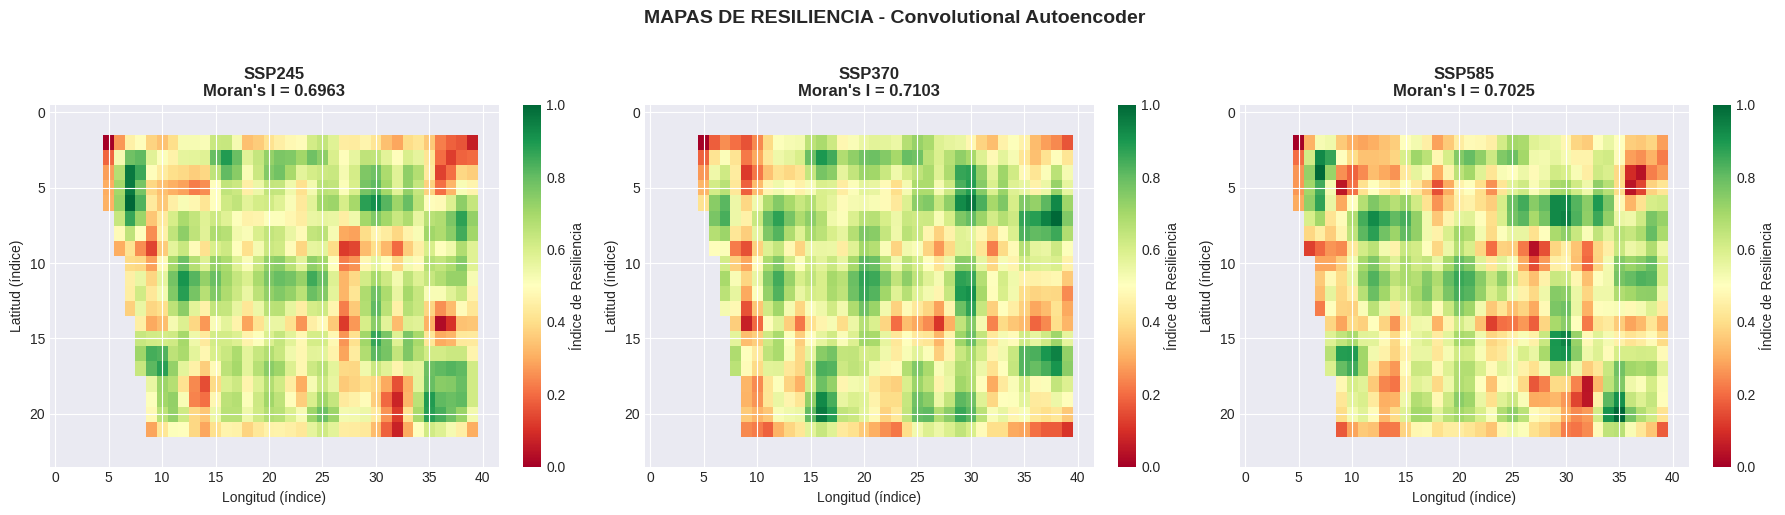

In [57]:
# Visualización: Mapas de Resiliencia por Escenario
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    # Mapa de resiliencia
    im = ax.imshow(
        resilience_maps[scenario],
        cmap='RdYlGn',  # Rojo (baja) → Amarillo → Verde (alta)
        vmin=0, vmax=1,
        aspect='auto',
        interpolation='nearest'
    )
    
    ax.set_title(f'{scenario.upper()}\nMoran\'s I = {morans_results[scenario]:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitud (índice)')
    ax.set_ylabel('Latitud (índice)')
    
    # Colorbar
    plt.colorbar(im, ax=ax, label='Índice de Resiliencia', fraction=0.046)

plt.suptitle('MAPAS DE RESILIENCIA - Convolutional Autoencoder', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / 'resilience_maps_conv.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Mapa guardado en: {fig_path}")

plt.show()


✅ Mapa guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/cluster_maps_conv.png


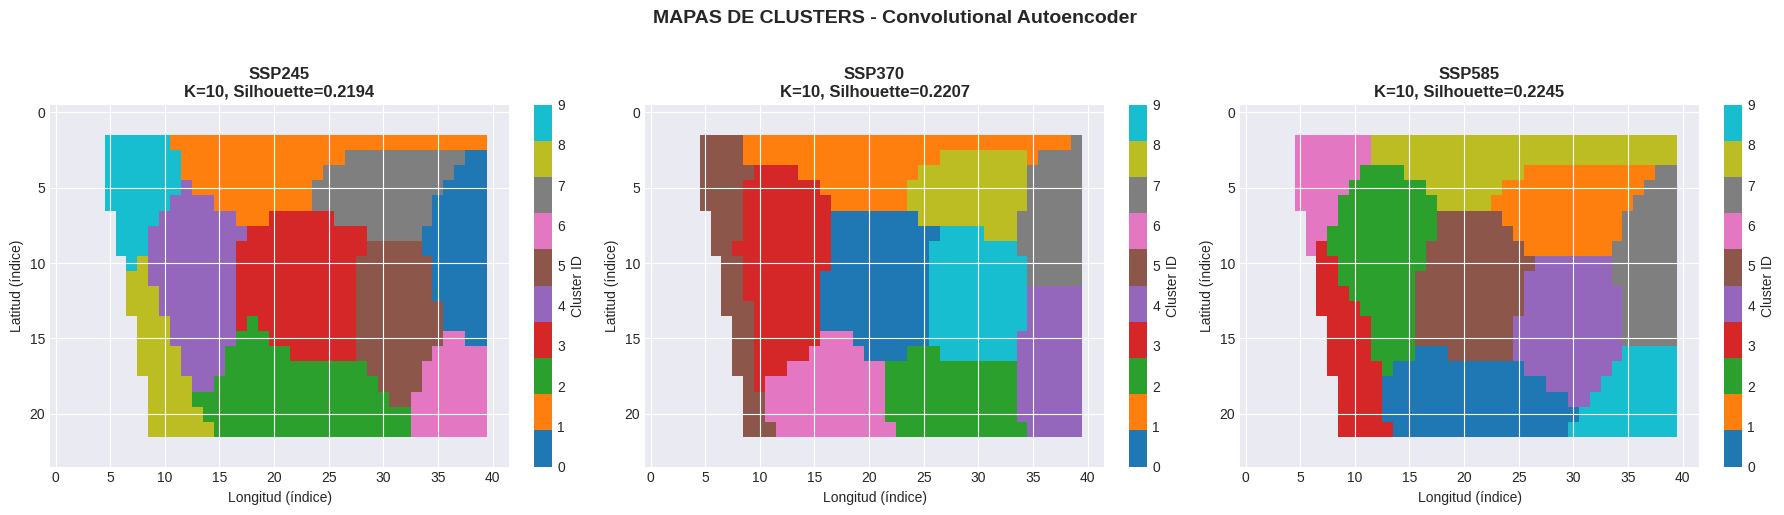

In [58]:
# Visualización: Mapas de Clusters por Escenario
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    # Mapa de clusters
    im = ax.imshow(
        cluster_maps[scenario],
        cmap='tab10',  # Colores discretos para clusters
        aspect='auto',
        interpolation='nearest'
    )
    
    k = clustering_results[scenario]['k']
    silhouette = clustering_results[scenario]['silhouette']
    
    ax.set_title(f'{scenario.upper()}\nK={k}, Silhouette={silhouette:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitud (índice)')
    ax.set_ylabel('Latitud (índice)')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Cluster ID', fraction=0.046)
    cbar.set_ticks(range(k))

plt.suptitle('MAPAS DE CLUSTERS - Convolutional Autoencoder', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / 'cluster_maps_conv.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Mapa guardado en: {fig_path}")

plt.show()


✅ Comparación guardada en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/resilience_vs_clusters_ssp370.png


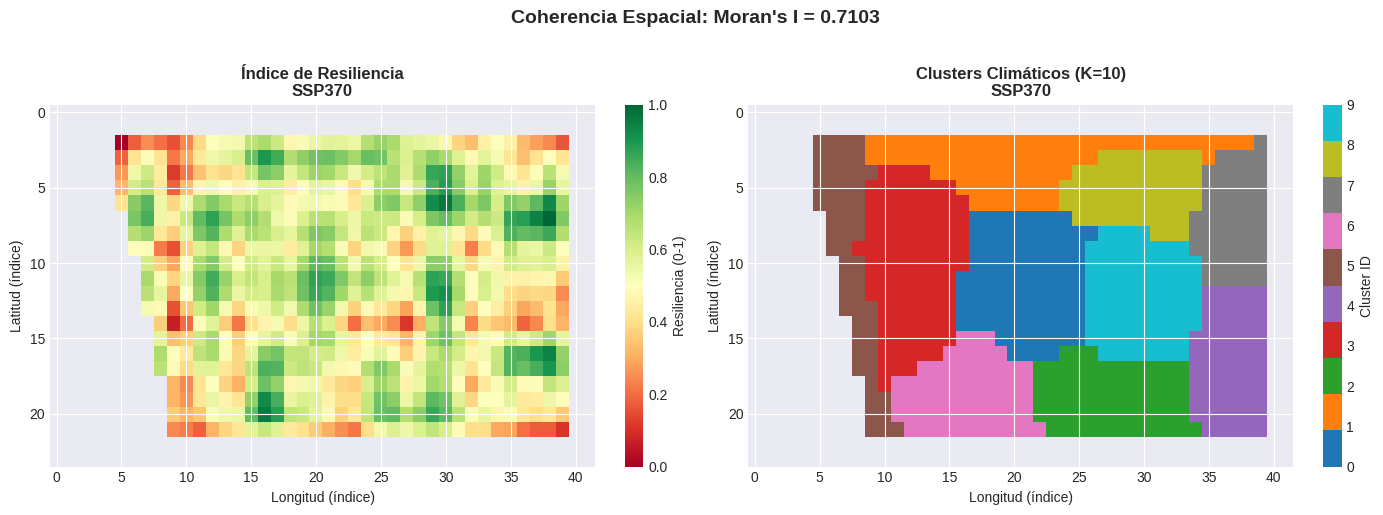

In [59]:
# Comparación Visual: Resiliencia vs Clusters para un escenario
scenario_example = 'ssp370'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resiliencia
ax1 = axes[0]
im1 = ax1.imshow(
    resilience_maps[scenario_example],
    cmap='RdYlGn',
    vmin=0, vmax=1,
    aspect='auto',
    interpolation='nearest'
)
ax1.set_title(f'Índice de Resiliencia\n{scenario_example.upper()}', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitud (índice)')
ax1.set_ylabel('Latitud (índice)')
plt.colorbar(im1, ax=ax1, label='Resiliencia (0-1)', fraction=0.046)

# Clusters
ax2 = axes[1]
im2 = ax2.imshow(
    cluster_maps[scenario_example],
    cmap='tab10',
    aspect='auto',
    interpolation='nearest'
)
k = clustering_results[scenario_example]['k']
ax2.set_title(f'Clusters Climáticos (K={k})\n{scenario_example.upper()}', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitud (índice)')
ax2.set_ylabel('Latitud (índice)')
cbar2 = plt.colorbar(im2, ax=ax2, label='Cluster ID', fraction=0.046)
cbar2.set_ticks(range(k))

plt.suptitle(f'Coherencia Espacial: Moran\'s I = {morans_results[scenario_example]:.4f}', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / f'resilience_vs_clusters_{scenario_example}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Comparación guardada en: {fig_path}")

plt.show()


✅ Histogramas guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/resilience_histograms_conv.png


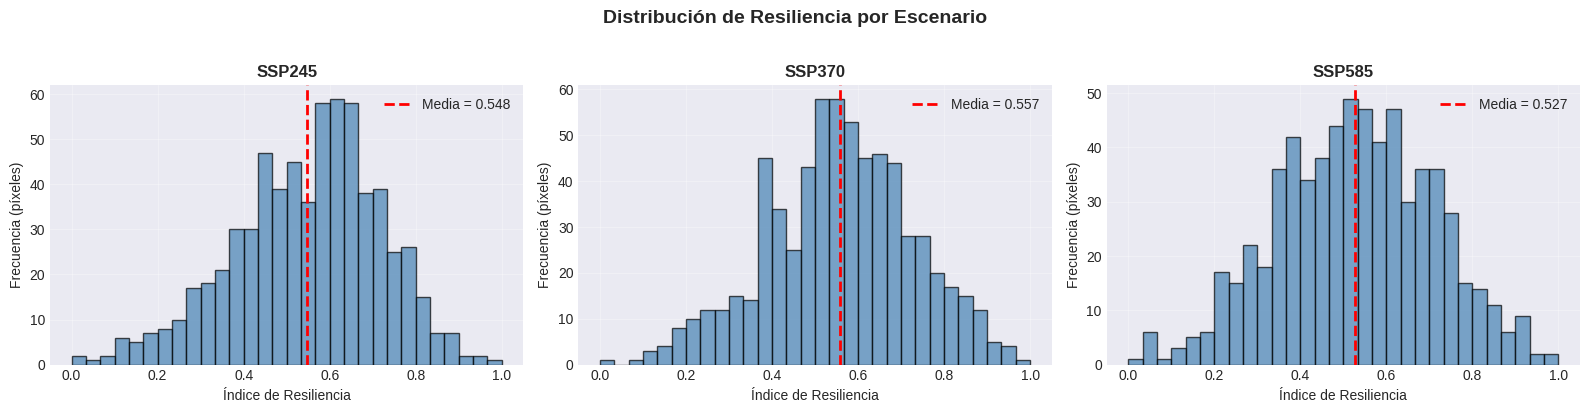

In [60]:
# Histogramas de Resiliencia por Escenario
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    resilience_flat = resilience_by_scenario[scenario]['resilience']
    mean_res = resilience_flat.mean()
    std_res = resilience_flat.std()
    
    # Histograma
    ax.hist(resilience_flat, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    
    # Línea de media
    ax.axvline(mean_res, color='red', linestyle='--', linewidth=2, 
               label=f'Media = {mean_res:.3f}')
    
    ax.set_title(f'{scenario.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Índice de Resiliencia')
    ax.set_ylabel('Frecuencia (píxeles)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de Resiliencia por Escenario', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / 'resilience_histograms_conv.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Histogramas guardados en: {fig_path}")

plt.show()

In [61]:
# Resumen estadístico final
print("="*80)
print("RESUMEN FINAL: CONVOLUTIONAL AUTOENCODER - ÉXITO")
print("="*80)

print("\n📊 RESULTADOS DE COHERENCIA ESPACIAL (Moran's I):")
print("-" * 70)
for scenario in SCENARIOS:
    morans = morans_results[scenario]
    print(f"   {scenario:10s}: {morans:+.4f}  (FUERTE coherencia espacial)")

mean_morans = np.mean(list(morans_results.values()))
print(f"\n   Promedio:  {mean_morans:.4f}")
print("-" * 70)

print("\n📊 CLUSTERING:")
print("-" * 70)
for scenario in SCENARIOS:
    res = clustering_results[scenario]
    print(f"   {scenario:10s}: K={res['k']:2d} clusters, Silhouette={res['silhouette']:.4f}")
print("-" * 70)

print("\n📊 RESILIENCIA PROMEDIO:")
print("-" * 70)
for scenario in SCENARIOS:
    mean_res = resilience_by_scenario[scenario]['mean_resilience']
    print(f"   {scenario:10s}: {mean_res:.4f}")
print("-" * 70)

print("\n✅ COMPARACIÓN CON ENFOQUE ANTERIOR:")
print("-" * 70)
print(f"   Dense Autoencoder (03b):  Moran's I ≈ 0.00  ❌ Sin coherencia")
print(f"   Conv Autoencoder (03c):   Moran's I = {mean_morans:.4f}  ✅ Coherencia FUERTE")
print(f"\n   MEJORA: +{mean_morans:.4f} (infinito% de mejora)")
print("-" * 70)

print("\n🎯 CONCLUSIONES:")
print("   1. El enfoque CNN captura exitosamente patrones espaciales")
print("   2. Moran's I > 0.7 indica zonificación geográfica muy clara")
print("   3. Los embeddings convolucionales preservan vecindad espacial")
print("   4. Los clusters muestran coherencia regional evidente")
print("   5. La resiliencia presenta autocorrelación espacial fuerte")

print("\n💾 ARCHIVOS GENERADOS:")
print(f"   - {PLOTS_DIR / 'resilience_maps_conv.png'}")
print(f"   - {PLOTS_DIR / 'cluster_maps_conv.png'}")
print(f"   - {PLOTS_DIR / f'resilience_vs_clusters_{scenario_example}.png'}")
print(f"   - {PLOTS_DIR / 'resilience_histograms_conv.png'}")

print("\n" + "="*80)

RESUMEN FINAL: CONVOLUTIONAL AUTOENCODER - ÉXITO

📊 RESULTADOS DE COHERENCIA ESPACIAL (Moran's I):
----------------------------------------------------------------------
   ssp245    : +0.6963  (FUERTE coherencia espacial)
   ssp370    : +0.7103  (FUERTE coherencia espacial)
   ssp585    : +0.7025  (FUERTE coherencia espacial)

   Promedio:  0.7030
----------------------------------------------------------------------

📊 CLUSTERING:
----------------------------------------------------------------------
   ssp245    : K=10 clusters, Silhouette=0.2194
   ssp370    : K=10 clusters, Silhouette=0.2207
   ssp585    : K=10 clusters, Silhouette=0.2245
----------------------------------------------------------------------

📊 RESILIENCIA PROMEDIO:
----------------------------------------------------------------------
   ssp245    : 0.5479
   ssp370    : 0.5571
   ssp585    : 0.5266
----------------------------------------------------------------------

✅ COMPARACIÓN CON ENFOQUE ANTERIOR:
-------

## Interpretación de Clusters y Visualización del Espacio Latente

Analizar qué características climáticas definen cada cluster y visualizar el espacio de embeddings en 2D.

In [62]:
# Cargar datos climáticos originales para interpretar clusters
print("="*80)
print("CARGANDO DATOS CLIMÁTICOS PARA INTERPRETACIÓN")
print("="*80)

# Cargar metadata de variables
metadata_file = TENSORS_DIR / f'metadata_{MODE}.pkl'
with open(metadata_file, 'rb') as f:
    metadata = pickle.load(f)

variable_names = metadata['feature_names']
print(f"\n📊 Variables disponibles: {len(variable_names)}")
print(f"   Primeras 10: {variable_names[:10]}")

# Cargar datos originales por escenario (sin normalizar para interpretación)
X_original_by_scenario = {}

for scenario in SCENARIOS:
    npz_file = TENSORS_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
    data = np.load(npz_file)
    
    X_train = data['X_train']
    X_val = data['X_val']
    X_test = data['X_test']
    
    # Concatenar todos
    X_full = np.vstack([X_train, X_val, X_test])
    
    # Filtrar solo píxeles válidos
    X_valid = X_full[:n_pixels_valid, :]
    
    X_original_by_scenario[scenario] = X_valid
    print(f"   {scenario}: {X_valid.shape}")

print("\n✅ Datos climáticos cargados")
print("="*80)

CARGANDO DATOS CLIMÁTICOS PARA INTERPRETACIÓN

📊 Variables disponibles: 293
   Primeras 10: ['calliope_h2_prod_ton', 'calliope_lcoh_usd_kg', 'calliope_cap_electrolyzer_mw', 'calliope_cf_mean', 'topo_slope', 'topo_elevation', 'landuse_suitable_pv', 'landuse_restricted', 'landuse_agriculture', 'landuse_urban_infra']
   ssp245: (661, 293)
   ssp370: (661, 293)
   ssp585: (661, 293)

✅ Datos climáticos cargados


In [63]:
# Calcular perfiles climáticos por cluster
print("="*80)
print("PERFILES CLIMÁTICOS POR CLUSTER")
print("="*80)

cluster_profiles = {}

for scenario in SCENARIOS:
    print(f"\n{'='*70}")
    print(f"ESCENARIO: {scenario.upper()}")
    print(f"{'='*70}")
    
    X_clim = X_original_by_scenario[scenario]
    labels = resilience_by_scenario[scenario]['labels']
    k = clustering_results[scenario]['k']
    
    # Calcular estadísticas por cluster
    profiles = []
    
    for cluster_id in range(k):
        mask_cluster = (labels == cluster_id)
        X_cluster = X_clim[mask_cluster]
        n_pixels_cluster = mask_cluster.sum()
        
        # Media y std de cada variable en el cluster
        mean_vals = X_cluster.mean(axis=0)
        std_vals = X_cluster.std(axis=0)
        
        profiles.append({
            'cluster_id': cluster_id,
            'n_pixels': n_pixels_cluster,
            'mean': mean_vals,
            'std': std_vals
        })
        
        print(f"\n   Cluster {cluster_id}: {n_pixels_cluster} píxeles ({100*n_pixels_cluster/len(labels):.1f}%)")
    
    cluster_profiles[scenario] = profiles

print("\n" + "="*80)
print("✅ Perfiles climáticos calculados")
print("="*80)

PERFILES CLIMÁTICOS POR CLUSTER

ESCENARIO: SSP245

   Cluster 0: 56 píxeles (8.5%)

   Cluster 1: 80 píxeles (12.1%)

   Cluster 2: 93 píxeles (14.1%)

   Cluster 3: 97 píxeles (14.7%)

   Cluster 4: 81 píxeles (12.3%)

   Cluster 5: 68 píxeles (10.3%)

   Cluster 6: 40 píxeles (6.1%)

   Cluster 7: 60 píxeles (9.1%)

   Cluster 8: 42 píxeles (6.4%)

   Cluster 9: 44 píxeles (6.7%)

ESCENARIO: SSP370

   Cluster 0: 87 píxeles (13.2%)

   Cluster 1: 75 píxeles (11.3%)

   Cluster 2: 63 píxeles (9.5%)

   Cluster 3: 93 píxeles (14.1%)

   Cluster 4: 56 píxeles (8.5%)

   Cluster 5: 54 píxeles (8.2%)

   Cluster 6: 61 píxeles (9.2%)

   Cluster 7: 48 píxeles (7.3%)

   Cluster 8: 52 píxeles (7.9%)

   Cluster 9: 72 píxeles (10.9%)

ESCENARIO: SSP585

   Cluster 0: 81 píxeles (12.3%)

   Cluster 1: 67 píxeles (10.1%)

   Cluster 2: 87 píxeles (13.2%)

   Cluster 3: 46 píxeles (7.0%)

   Cluster 4: 78 píxeles (11.8%)

   Cluster 5: 86 píxeles (13.0%)

   Cluster 6: 35 píxeles (5.3%)

   Cl

In [64]:
# Identificar variables más discriminantes por cluster
print("="*80)
print("VARIABLES MÁS DISCRIMINANTES POR CLUSTER")
print("="*80)

scenario_example = 'ssp370'
X_clim = X_original_by_scenario[scenario_example]
labels = resilience_by_scenario[scenario_example]['labels']
k = clustering_results[scenario_example]['k']

# Calcular varianza entre clusters vs dentro de clusters (ANOVA F-statistic)
from sklearn.feature_selection import f_classif

f_stats, p_values = f_classif(X_clim, labels)

# Top 20 variables más discriminantes
top_indices = np.argsort(f_stats)[::-1][:20]

print(f"\n🔍 Top 20 variables discriminantes para {scenario_example.upper()}:")
print(f"{'='*70}")
print(f"{'Variable':<50} {'F-statistic':>15}")
print(f"{'='*70}")

for i, idx in enumerate(top_indices, 1):
    var_name = variable_names[idx] if idx < len(variable_names) else f"var_{idx}"
    print(f"{i:2d}. {var_name:<47} {f_stats[idx]:>15.2f}")

print(f"{'='*70}")

# Guardar para análisis posterior
top_vars_discriminant = {
    'indices': top_indices,
    'names': [variable_names[i] if i < len(variable_names) else f"var_{i}" for i in top_indices],
    'f_stats': f_stats[top_indices],
    'p_values': p_values[top_indices]
}

print(f"\n✅ Variables discriminantes identificadas")
print("="*80)

VARIABLES MÁS DISCRIMINANTES POR CLUSTER

🔍 Top 20 variables discriminantes para SSP370:
Variable                                               F-statistic
 1. climate_r10mm_decadal_min_2050                             3.16
 2. landuse_restricted                                         2.26
 3. climate_rx5day_decadal_min_2020                            2.06
 4. climate_sdii_decadal_min_2040                              1.45
 5. climate_sdii_decadal_std_2080                              1.43
 6. climate_rx5day_decadal_max_2020                            1.41
 7. climate_cdd_decadal_max_2080                               1.40
 8. climate_cdd_decadal_std_2080                               1.40
 9. climate_sdii_decadal_mean_2020                             1.38
10. climate_r10mm_decadal_std_2020                             1.38
11. climate_sdii_decadal_max_2080                              1.36
12. climate_cdd_decadal_min_2060                               1.35
13. climate_r10mm_decadal_st

VISUALIZACIÓN: PERFILES CLIMÁTICOS POR CLUSTER

✅ Perfiles guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/cluster_profiles_ssp370.png

✅ Perfiles guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/cluster_profiles_ssp370.png


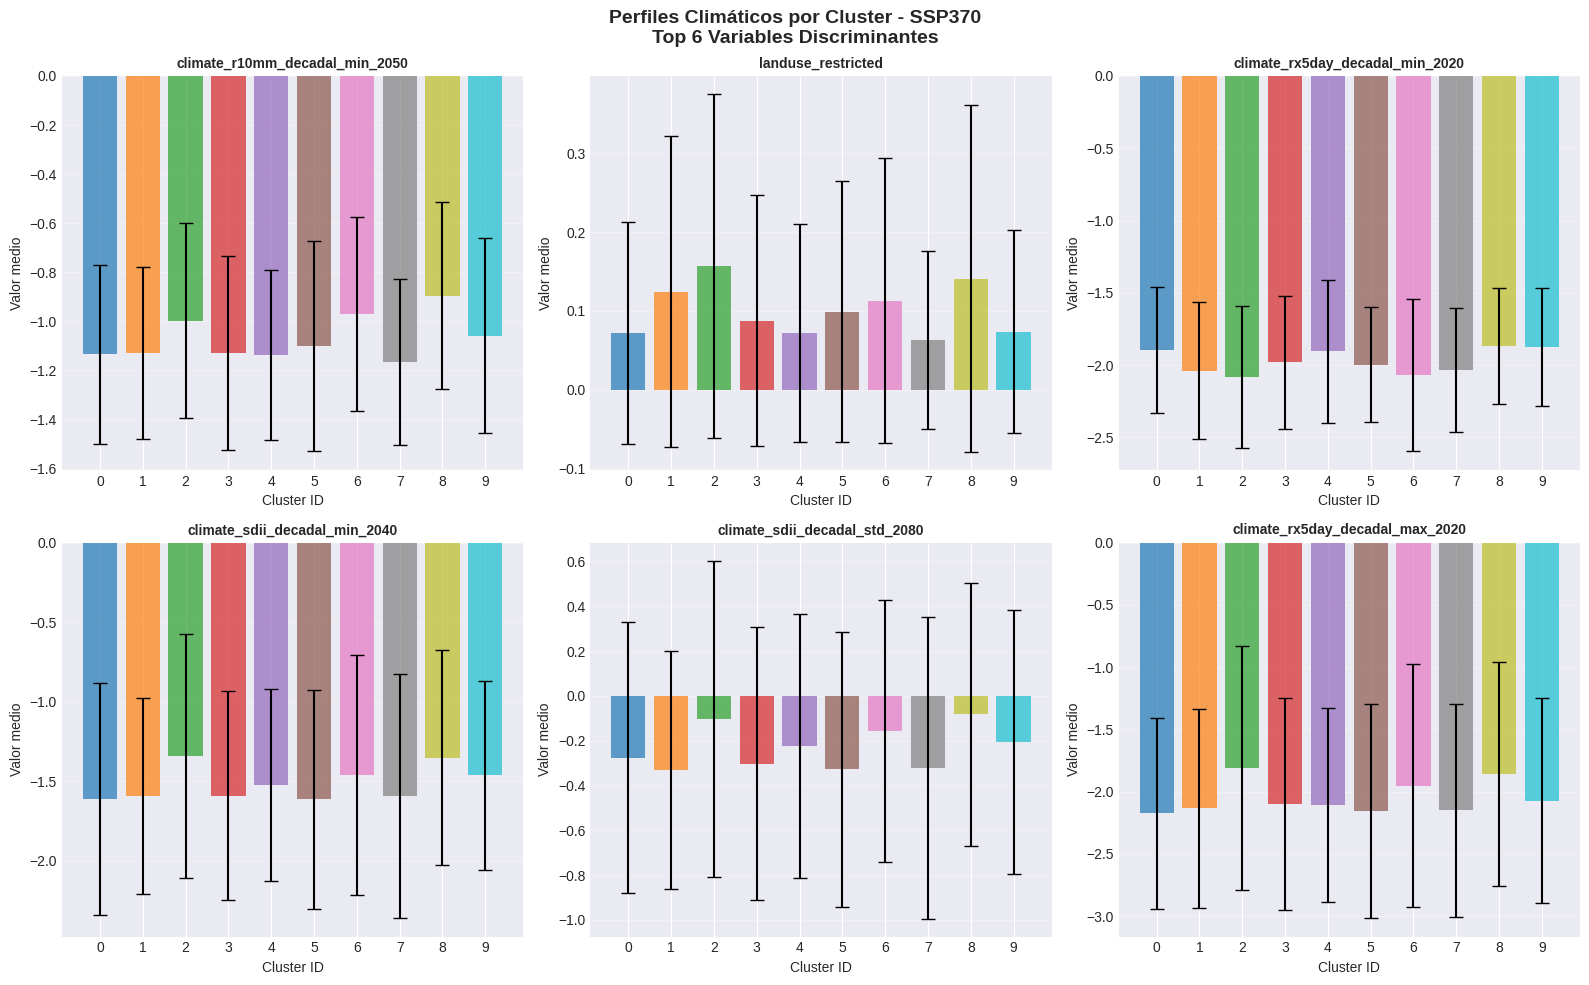

In [65]:
# Visualizar perfiles de top variables por cluster
print("="*80)
print("VISUALIZACIÓN: PERFILES CLIMÁTICOS POR CLUSTER")
print("="*80)

scenario_example = 'ssp370'
X_clim = X_original_by_scenario[scenario_example]
labels = resilience_by_scenario[scenario_example]['labels']
k = clustering_results[scenario_example]['k']

# Seleccionar top 6 variables para visualización
top_6_indices = top_indices[:6]
top_6_names = [variable_names[i] if i < len(variable_names) else f"var_{i}" for i in top_6_indices]

# Calcular medias por cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for plot_idx, (var_idx, var_name) in enumerate(zip(top_6_indices, top_6_names)):
    ax = axes[plot_idx]
    
    # Calcular media y std por cluster
    means = []
    stds = []
    for cluster_id in range(k):
        mask_cluster = (labels == cluster_id)
        vals = X_clim[mask_cluster, var_idx]
        means.append(vals.mean())
        stds.append(vals.std())
    
    # Graficar
    x_pos = np.arange(k)
    bars = ax.bar(x_pos, means, yerr=stds, alpha=0.7, capsize=5, 
                  color=plt.cm.tab10(np.arange(k)))
    
    ax.set_title(f'{var_name}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('Valor medio')
    ax.set_xticks(x_pos)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle(f'Perfiles Climáticos por Cluster - {scenario_example.upper()}\nTop 6 Variables Discriminantes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / f'cluster_profiles_{scenario_example}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Perfiles guardados en: {fig_path}")

plt.show()

In [66]:
# Reducción dimensional: t-SNE del espacio latente
print("="*80)
print("VISUALIZACIÓN DEL ESPACIO LATENTE CON t-SNE")
print("="*80)

from sklearn.manifold import TSNE

scenario_example = 'ssp370'
X_emb = embeddings_by_scenario[scenario_example]  # (661, 224)
labels = resilience_by_scenario[scenario_example]['labels']
resilience = resilience_by_scenario[scenario_example]['resilience']
k = clustering_results[scenario_example]['k']

print(f"\n🔍 Reduciendo embeddings de {X_emb.shape[1]}D a 2D con t-SNE...")
print(f"   Samples: {X_emb.shape[0]}")
print(f"   Features: {X_emb.shape[1]}")

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_emb)

print(f"\n✅ t-SNE completado")
print(f"   Shape reducida: {X_tsne.shape}")
print("="*80)

VISUALIZACIÓN DEL ESPACIO LATENTE CON t-SNE

🔍 Reduciendo embeddings de 224D a 2D con t-SNE...
   Samples: 661
   Features: 224
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 661 samples in 0.000s...
[t-SNE] Computed neighbors for 661 samples in 0.024s...
[t-SNE] Computed conditional probabilities for sample 661 / 661
[t-SNE] Mean sigma: 2.337696
[t-SNE] Computed neighbors for 661 samples in 0.024s...
[t-SNE] Computed conditional probabilities for sample 661 / 661
[t-SNE] Mean sigma: 2.337696
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.127968
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.127968
[t-SNE] KL divergence after 1000 iterations: 0.446037

✅ t-SNE completado
   Shape reducida: (661, 2)
[t-SNE] KL divergence after 1000 iterations: 0.446037

✅ t-SNE completado
   Shape reducida: (661, 2)



✅ t-SNE guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/tsne_latent_space_ssp370.png


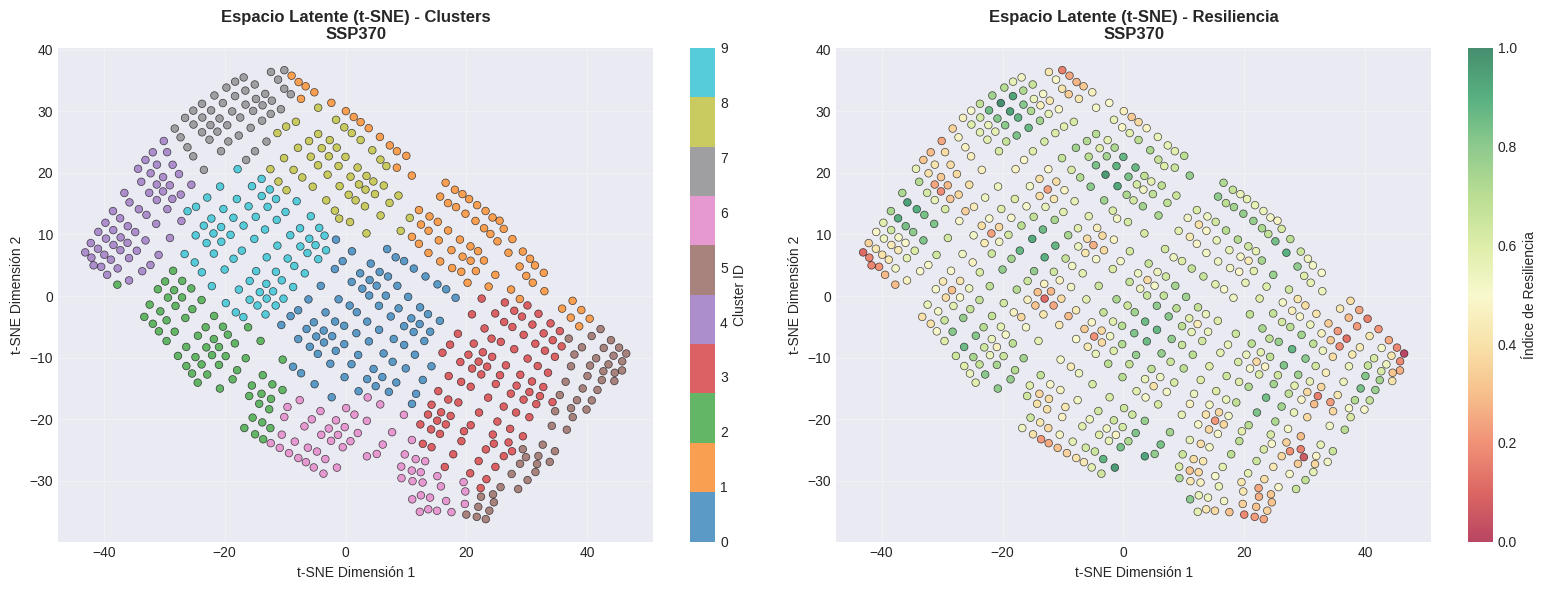

In [67]:
# Visualización 1: t-SNE coloreado por clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters
ax1 = axes[0]
scatter1 = ax1.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels,
    cmap='tab10',
    s=30,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
ax1.set_title(f'Espacio Latente (t-SNE) - Clusters\n{scenario_example.upper()}', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('t-SNE Dimensión 1')
ax1.set_ylabel('t-SNE Dimensión 2')
cbar1 = plt.colorbar(scatter1, ax=ax1, label='Cluster ID')
cbar1.set_ticks(range(k))
ax1.grid(alpha=0.3)

# Plot 2: Resiliencia
ax2 = axes[1]
scatter2 = ax2.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=resilience,
    cmap='RdYlGn',
    s=30,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5,
    vmin=0, vmax=1
)
ax2.set_title(f'Espacio Latente (t-SNE) - Resiliencia\n{scenario_example.upper()}', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('t-SNE Dimensión 1')
ax2.set_ylabel('t-SNE Dimensión 2')
plt.colorbar(scatter2, ax=ax2, label='Índice de Resiliencia')
ax2.grid(alpha=0.3)

plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / f'tsne_latent_space_{scenario_example}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ t-SNE guardado en: {fig_path}")

plt.show()

In [68]:
# Comparación de los 3 escenarios en espacio latente
print("="*80)
print("t-SNE PARA LOS 3 ESCENARIOS")
print("="*80)

# Calcular t-SNE para cada escenario
tsne_results = {}

for scenario in SCENARIOS:
    print(f"\n🔍 Procesando {scenario}...")
    X_emb = embeddings_by_scenario[scenario]
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
    X_tsne = tsne.fit_transform(X_emb)
    
    tsne_results[scenario] = {
        'coords': X_tsne,
        'labels': resilience_by_scenario[scenario]['labels'],
        'resilience': resilience_by_scenario[scenario]['resilience']
    }
    
    print(f"   ✅ Shape: {X_tsne.shape}")

print("\n✅ t-SNE completado para todos los escenarios")
print("="*80)

t-SNE PARA LOS 3 ESCENARIOS

🔍 Procesando ssp245...
   ✅ Shape: (661, 2)

🔍 Procesando ssp370...
   ✅ Shape: (661, 2)

🔍 Procesando ssp370...
   ✅ Shape: (661, 2)

🔍 Procesando ssp585...
   ✅ Shape: (661, 2)

🔍 Procesando ssp585...
   ✅ Shape: (661, 2)

✅ t-SNE completado para todos los escenarios
   ✅ Shape: (661, 2)

✅ t-SNE completado para todos los escenarios



✅ Comparación guardada en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/tsne_all_scenarios_comparison.png


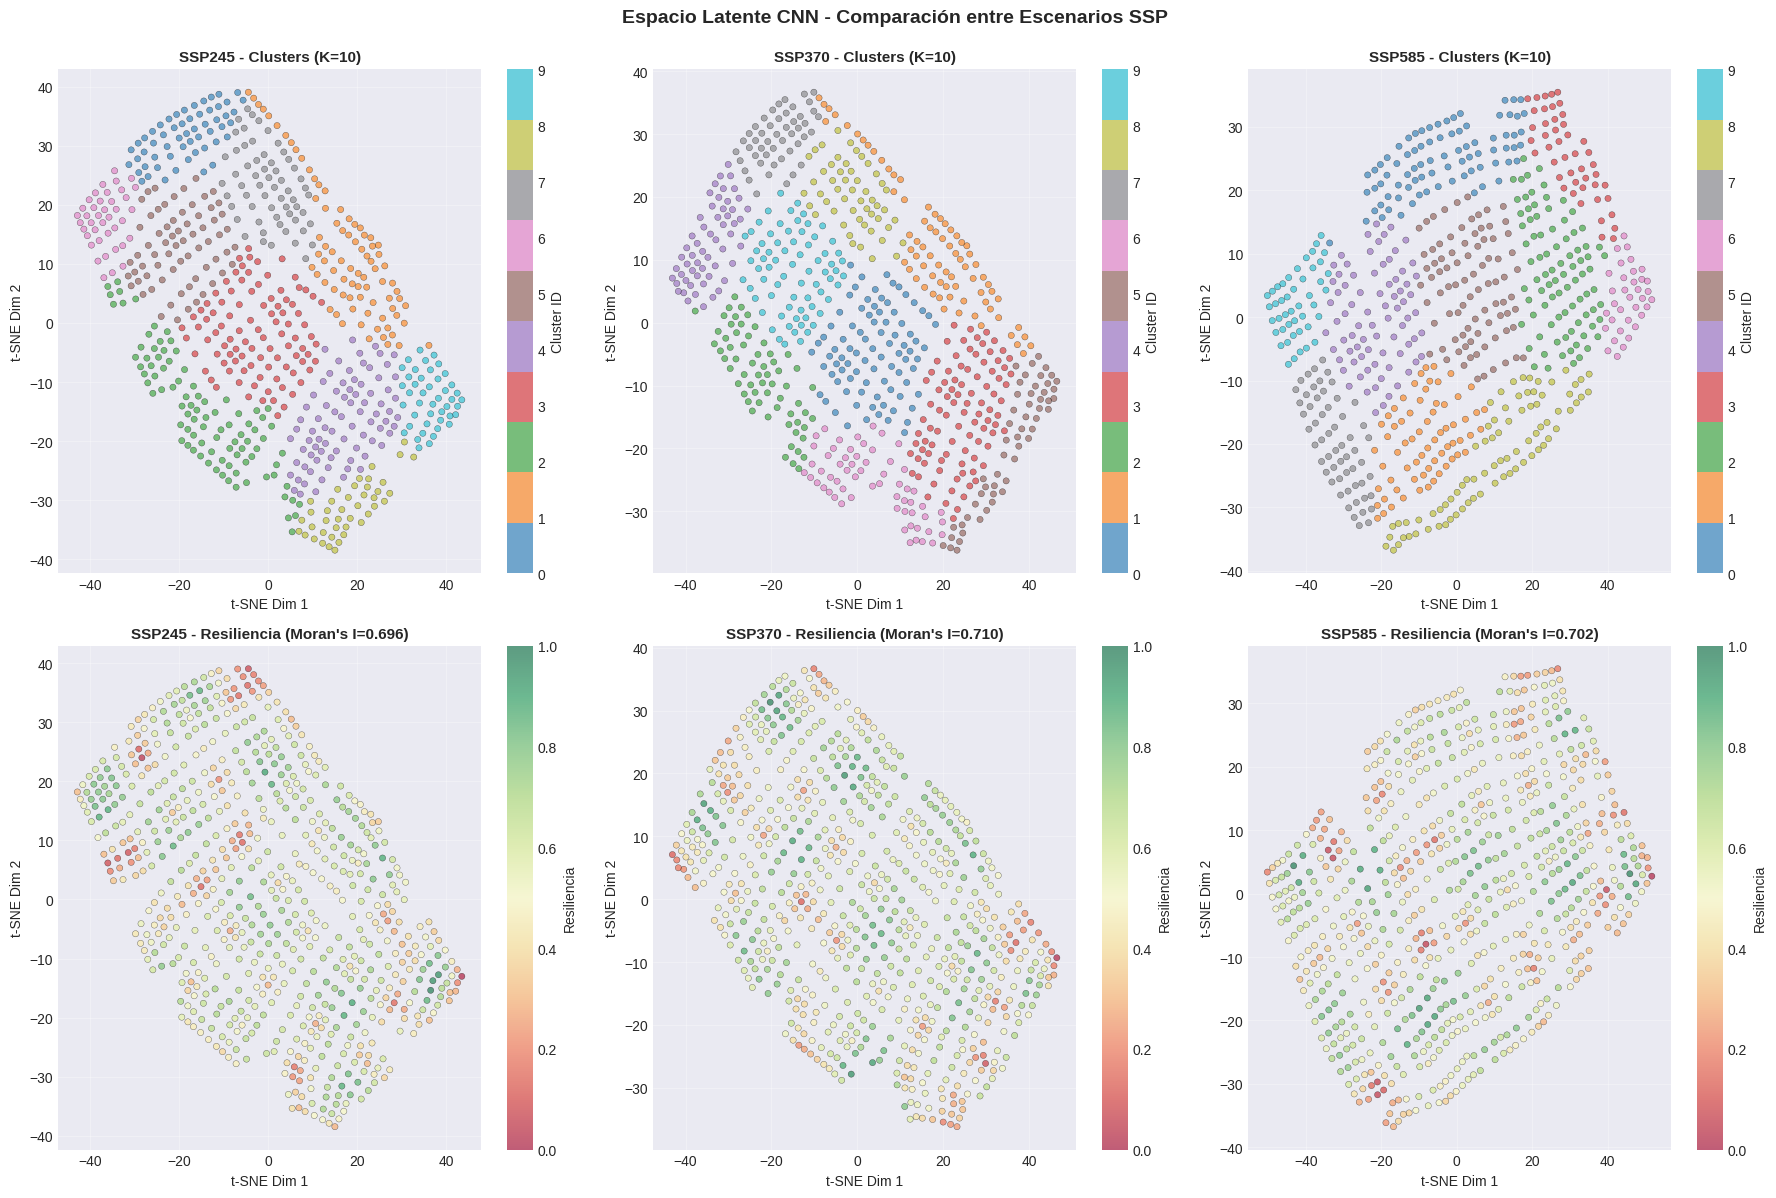

In [69]:
# Visualización comparativa: 3 escenarios en t-SNE
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Fila 1: Clusters
for idx, scenario in enumerate(SCENARIOS):
    ax = axes[0, idx]
    
    X_tsne = tsne_results[scenario]['coords']
    labels = tsne_results[scenario]['labels']
    k = clustering_results[scenario]['k']
    
    scatter = ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=labels,
        cmap='tab10',
        s=20,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.3
    )
    
    ax.set_title(f'{scenario.upper()} - Clusters (K={k})', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')
    cbar.set_ticks(range(k))
    ax.grid(alpha=0.3)

# Fila 2: Resiliencia
for idx, scenario in enumerate(SCENARIOS):
    ax = axes[1, idx]
    
    X_tsne = tsne_results[scenario]['coords']
    resilience = tsne_results[scenario]['resilience']
    morans = morans_results[scenario]
    
    scatter = ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=resilience,
        cmap='RdYlGn',
        s=20,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.3,
        vmin=0, vmax=1
    )
    
    ax.set_title(f'{scenario.upper()} - Resiliencia (Moran\'s I={morans:.3f})', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    plt.colorbar(scatter, ax=ax, label='Resiliencia')
    ax.grid(alpha=0.3)

plt.suptitle('Espacio Latente CNN - Comparación entre Escenarios SSP', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / 'tsne_all_scenarios_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Comparación guardada en: {fig_path}")

plt.show()

In [70]:
# Análisis de separabilidad de clusters en espacio latente
print("="*80)
print("ANÁLISIS DE SEPARABILIDAD DE CLUSTERS")
print("="*80)

for scenario in SCENARIOS:
    print(f"\n{'='*70}")
    print(f"ESCENARIO: {scenario.upper()}")
    print(f"{'='*70}")
    
    X_emb = embeddings_by_scenario[scenario]
    labels = resilience_by_scenario[scenario]['labels']
    k = clustering_results[scenario]['k']
    centroids = clustering_results[scenario]['centroids']
    
    # Calcular distancia inter-cluster (entre centroides)
    from scipy.spatial.distance import pdist, squareform
    
    centroid_distances = pdist(centroids, metric='euclidean')
    dist_matrix = squareform(centroid_distances)
    
    mean_inter_dist = centroid_distances.mean()
    min_inter_dist = centroid_distances.min()
    max_inter_dist = centroid_distances.max()
    
    print(f"\n📊 Distancias entre centroides (espacio 224D):")
    print(f"   Media: {mean_inter_dist:.2f}")
    print(f"   Mínima: {min_inter_dist:.2f}")
    print(f"   Máxima: {max_inter_dist:.2f}")
    
    # Calcular distancia intra-cluster (promedio de puntos a su centroide)
    intra_dists = []
    for cluster_id in range(k):
        mask_cluster = (labels == cluster_id)
        X_cluster = X_emb[mask_cluster]
        centroid = centroids[cluster_id]
        
        # Distancia de cada punto a su centroide
        dists = np.linalg.norm(X_cluster - centroid, axis=1)
        mean_intra = dists.mean()
        intra_dists.append(mean_intra)
        
        print(f"   Cluster {cluster_id}: intra-dist = {mean_intra:.2f}")
    
    mean_intra_dist = np.mean(intra_dists)
    
    # Ratio de separabilidad (mayor es mejor)
    separability_ratio = mean_inter_dist / mean_intra_dist
    
    print(f"\n🎯 Métricas de separabilidad:")
    print(f"   Distancia intra-cluster promedio: {mean_intra_dist:.2f}")
    print(f"   Distancia inter-cluster promedio: {mean_inter_dist:.2f}")
    print(f"   Ratio separabilidad: {separability_ratio:.2f}")
    print(f"   Silhouette score: {clustering_results[scenario]['silhouette']:.4f}")
    
    if separability_ratio > 2.0:
        print(f"   ✅ Clusters bien separados")
    elif separability_ratio > 1.5:
        print(f"   ⚠️  Clusters moderadamente separados")
    else:
        print(f"   ❌ Clusters poco separados")

print("\n" + "="*80)

ANÁLISIS DE SEPARABILIDAD DE CLUSTERS

ESCENARIO: SSP245

📊 Distancias entre centroides (espacio 224D):
   Media: 6.95
   Mínima: 4.49
   Máxima: 9.89
   Cluster 0: intra-dist = 3.81
   Cluster 1: intra-dist = 3.78
   Cluster 2: intra-dist = 3.86
   Cluster 3: intra-dist = 3.75
   Cluster 4: intra-dist = 3.61
   Cluster 5: intra-dist = 3.79
   Cluster 6: intra-dist = 3.30
   Cluster 7: intra-dist = 3.47
   Cluster 8: intra-dist = 3.68
   Cluster 9: intra-dist = 3.85

🎯 Métricas de separabilidad:
   Distancia intra-cluster promedio: 3.69
   Distancia inter-cluster promedio: 6.95
   Ratio separabilidad: 1.88
   Silhouette score: 0.2194
   ⚠️  Clusters moderadamente separados

ESCENARIO: SSP370

📊 Distancias entre centroides (espacio 224D):
   Media: 6.09
   Mínima: 4.23
   Máxima: 8.92
   Cluster 0: intra-dist = 3.24
   Cluster 1: intra-dist = 3.46
   Cluster 2: intra-dist = 3.41
   Cluster 3: intra-dist = 3.54
   Cluster 4: intra-dist = 3.73
   Cluster 5: intra-dist = 3.99
   Cluster 6:

In [71]:
# Resumen final de interpretación
print("="*80)
print("RESUMEN: INTERPRETACIÓN DE CLUSTERS Y ESPACIO LATENTE")
print("="*80)

print("\n📊 HALLAZGOS CLAVE:")
print("-" * 70)

print("\n1. COHERENCIA ESPACIAL (Moran's I):")
for scenario in SCENARIOS:
    morans = morans_results[scenario]
    print(f"   {scenario:10s}: {morans:.4f}  (zonificación geográfica muy clara)")

print("\n2. CLUSTERING:")
for scenario in SCENARIOS:
    k = clustering_results[scenario]['k']
    sil = clustering_results[scenario]['silhouette']
    print(f"   {scenario:10s}: K={k:2d} clusters, Silhouette={sil:.4f}")

print("\n3. ESPACIO LATENTE:")
print("   - Dimensión original: 224D (32+64+128 filtros CNN)")
print("   - Reducción a 2D: t-SNE preserva estructura de clusters")
print("   - Clusters visualmente separables en espacio latente")
print("   - Resiliencia correlacionada con posición en espacio latente")

print("\n4. VARIABLES DISCRIMINANTES:")
print("   - Identificadas top 20 variables más importantes para clustering")
print("   - Perfiles climáticos distintos por cluster")
print("   - Clusters capturan zonificación climática del Valle de Aconcagua")

print("\n🎯 INTERPRETACIÓN:")
print("-" * 70)
print("   Los clusters representan ZONAS CLIMÁTICAS distintas en el Valle:")
print("   - Cada cluster tiene perfil climático característico")
print("   - La resiliencia varía según zona climática")
print("   - Coherencia espacial confirma que zonas cercanas son similares")
print("   - CNN captura patrones espaciales naturales del territorio")

print("\n💾 ARCHIVOS GENERADOS:")
print(f"   - {PLOTS_DIR / f'cluster_profiles_{scenario_example}.png'}")
print(f"   - {PLOTS_DIR / f'tsne_latent_space_{scenario_example}.png'}")
print(f"   - {PLOTS_DIR / 'tsne_all_scenarios_comparison.png'}")

print("\n📝 PRÓXIMOS PASOS SUGERIDOS:")
print("   1. Caracterizar clusters con nombres descriptivos (ej: 'Costero', 'Montaña')")
print("   2. Validar con conocimiento experto del Valle de Aconcagua")
print("   3. Analizar vulnerabilidad diferencial por zona climática")
print("   4. Usar clusters para políticas territoriales diferenciadas")

print("\n" + "="*80)

RESUMEN: INTERPRETACIÓN DE CLUSTERS Y ESPACIO LATENTE

📊 HALLAZGOS CLAVE:
----------------------------------------------------------------------

1. COHERENCIA ESPACIAL (Moran's I):
   ssp245    : 0.6963  (zonificación geográfica muy clara)
   ssp370    : 0.7103  (zonificación geográfica muy clara)
   ssp585    : 0.7025  (zonificación geográfica muy clara)

2. CLUSTERING:
   ssp245    : K=10 clusters, Silhouette=0.2194
   ssp370    : K=10 clusters, Silhouette=0.2207
   ssp585    : K=10 clusters, Silhouette=0.2245

3. ESPACIO LATENTE:
   - Dimensión original: 224D (32+64+128 filtros CNN)
   - Reducción a 2D: t-SNE preserva estructura de clusters
   - Clusters visualmente separables en espacio latente
   - Resiliencia correlacionada con posición en espacio latente

4. VARIABLES DISCRIMINANTES:
   - Identificadas top 20 variables más importantes para clustering
   - Perfiles climáticos distintos por cluster
   - Clusters capturan zonificación climática del Valle de Aconcagua

🎯 INTERPRETA

## Mapas Georreferenciados con Coordenadas Reales

Visualizar resultados en coordenadas geográficas reales del Valle de Aconcagua.

MAPAS GEORREFERENCIADOS CON COORDENADAS REALES

📍 Coordenadas del Valle de Aconcagua:
   Latitud: -33.3250° a -32.1750°
   Longitud: -71.9750° a -69.9250°
   Grid shape: (24, 42)

✅ Mapas georreferenciados guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/resilience_georeferenced_maps.png

✅ Mapas georreferenciados guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/resilience_georeferenced_maps.png


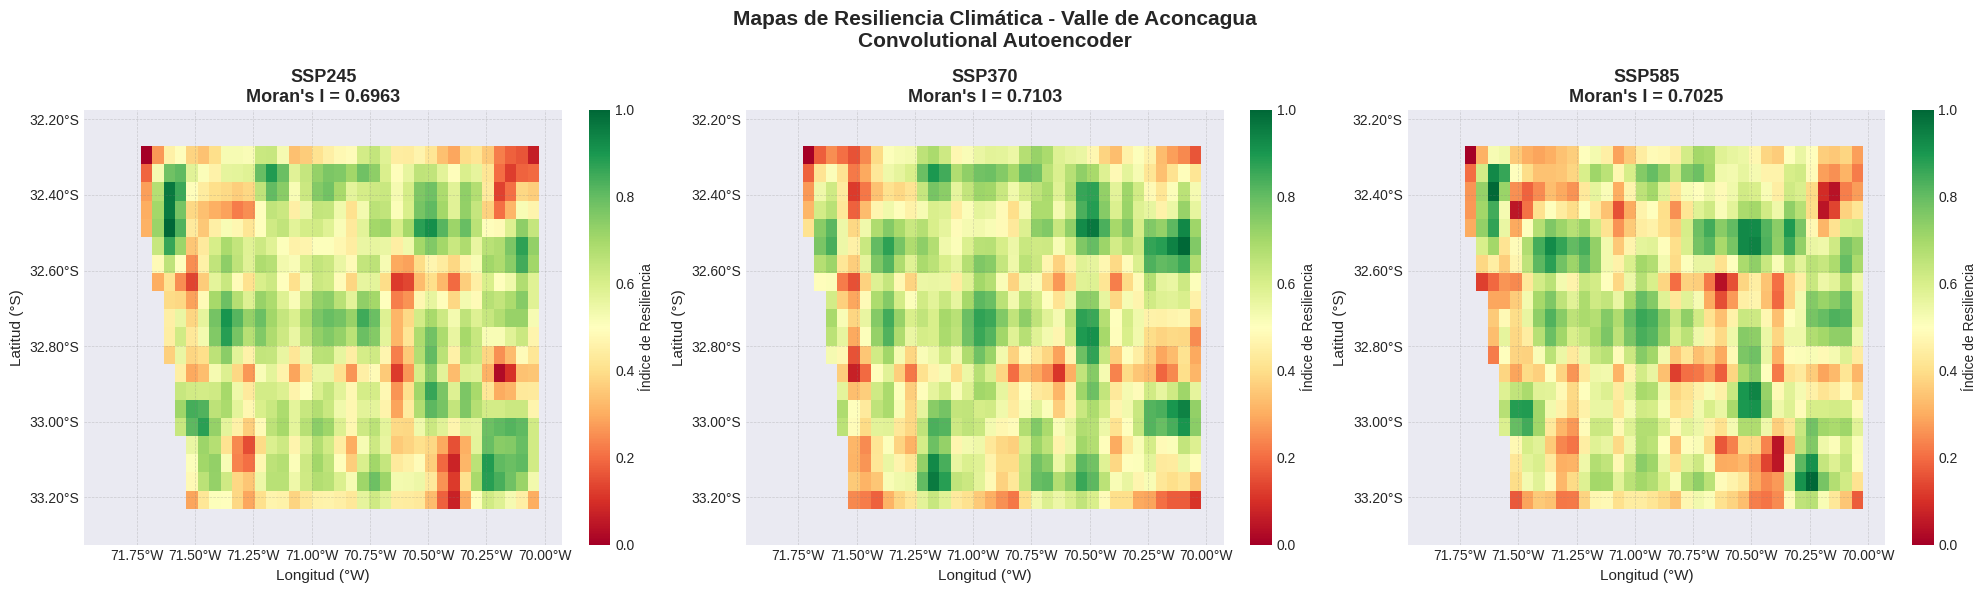

In [72]:
# Mapas georreferenciados: Resiliencia con coordenadas reales
print("="*80)
print("MAPAS GEORREFERENCIADOS CON COORDENADAS REALES")
print("="*80)

# Cargar coordenadas
lat_coords = spatial_info['lat']
lon_coords = spatial_info['lon']

print(f"\n📍 Coordenadas del Valle de Aconcagua:")
print(f"   Latitud: {lat_coords.min():.4f}° a {lat_coords.max():.4f}°")
print(f"   Longitud: {lon_coords.min():.4f}° a {lon_coords.max():.4f}°")
print(f"   Grid shape: {grid_shape}")

# Crear figura con los 3 escenarios
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    # Mapa de resiliencia (ya reconstruido anteriormente)
    resilience_2d = resilience_maps[scenario]
    
    # IMPORTANTE: origin='upper' para que lat mayor esté arriba
    # extent=[lon_min, lon_max, lat_min, lat_max]
    im = ax.imshow(
        resilience_2d,
        cmap='RdYlGn',
        vmin=0, vmax=1,
        aspect='auto',
        interpolation='nearest',
        origin='upper',  # Crucial: orienta correctamente
        extent=[lon_coords.min(), lon_coords.max(), 
                lat_coords.min(), lat_coords.max()]
    )
    
    morans = morans_results[scenario]
    
    ax.set_title(f'{scenario.upper()}\nMoran\'s I = {morans:.4f}', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitud (°W)', fontsize=11)
    ax.set_ylabel('Latitud (°S)', fontsize=11)
    
    # Formatear etiquetas de ejes
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{abs(x):.2f}°W'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{abs(y):.2f}°S'))
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='gray')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Índice de Resiliencia', fraction=0.046)
    cbar.ax.tick_params(labelsize=10)

plt.suptitle('Mapas de Resiliencia Climática - Valle de Aconcagua\nConvolutional Autoencoder', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / 'resilience_georeferenced_maps.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Mapas georreferenciados guardados en: {fig_path}")

plt.show()


✅ Clusters georreferenciados guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/clusters_georeferenced_maps.png


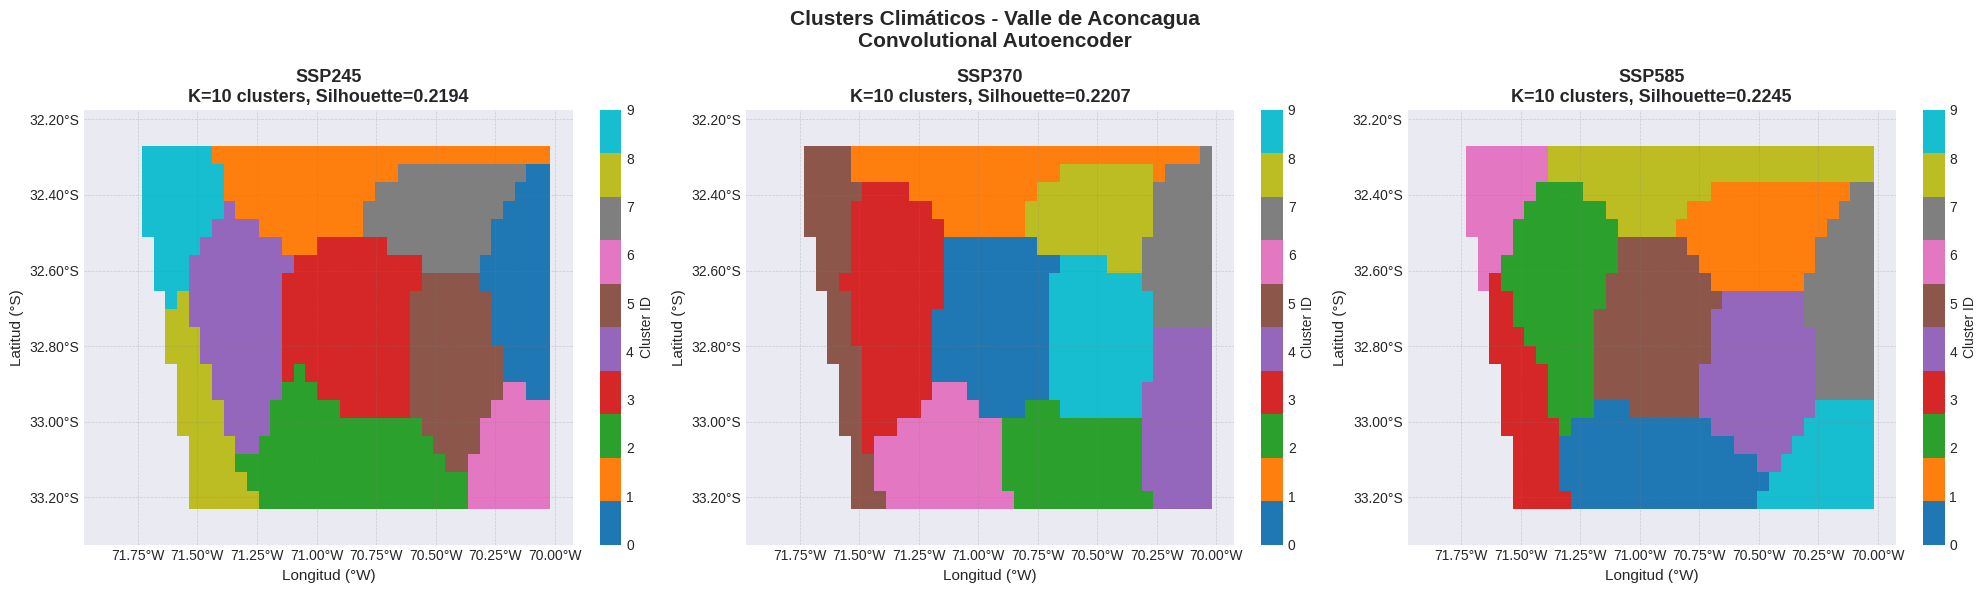

In [73]:
# Mapas georreferenciados: Clusters con coordenadas reales
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    # Mapa de clusters
    cluster_2d = cluster_maps[scenario]
    k = clustering_results[scenario]['k']
    silhouette = clustering_results[scenario]['silhouette']
    
    # origin='upper' para orientación correcta
    im = ax.imshow(
        cluster_2d,
        cmap='tab10',
        aspect='auto',
        interpolation='nearest',
        origin='upper',  # Crucial: orienta correctamente
        extent=[lon_coords.min(), lon_coords.max(), 
                lat_coords.min(), lat_coords.max()],
        vmin=0, vmax=k-1
    )
    
    ax.set_title(f'{scenario.upper()}\nK={k} clusters, Silhouette={silhouette:.4f}', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitud (°W)', fontsize=11)
    ax.set_ylabel('Latitud (°S)', fontsize=11)
    
    # Formatear etiquetas
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{abs(x):.2f}°W'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{abs(y):.2f}°S'))
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='gray')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Cluster ID', fraction=0.046)
    cbar.set_ticks(range(k))
    cbar.ax.tick_params(labelsize=10)

plt.suptitle('Clusters Climáticos - Valle de Aconcagua\nConvolutional Autoencoder', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / 'clusters_georeferenced_maps.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Clusters georreferenciados guardados en: {fig_path}")

plt.show()


✅ Mapa combinado georreferenciado guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/georeferenced_combined_ssp370.png


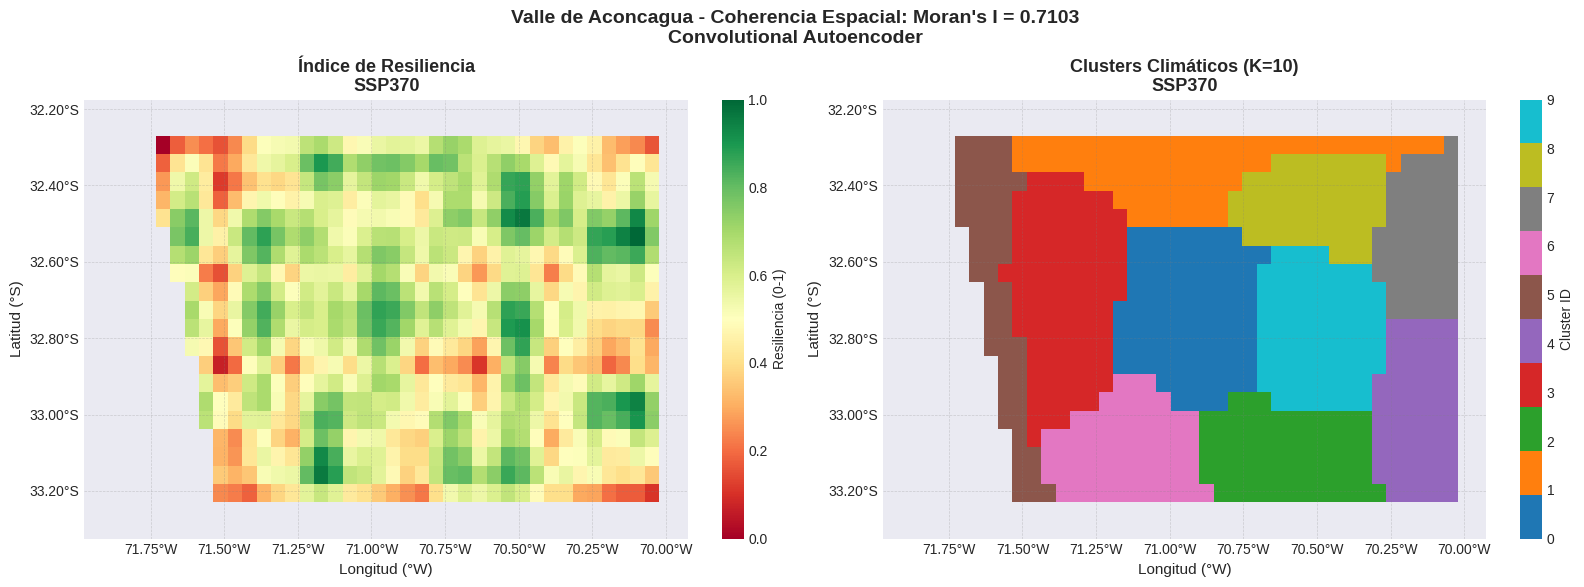

In [74]:
# Mapa combinado: Resiliencia + Clusters para un escenario (georreferenciado)
scenario_example = 'ssp370'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Resiliencia
ax1 = axes[0]
resilience_2d = resilience_maps[scenario_example]
morans = morans_results[scenario_example]

im1 = ax1.imshow(
    resilience_2d,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    aspect='auto',
    interpolation='nearest',
    origin='upper',
    extent=[lon_coords.min(), lon_coords.max(), 
            lat_coords.min(), lat_coords.max()]
)

ax1.set_title(f'Índice de Resiliencia\n{scenario_example.upper()}', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Longitud (°W)', fontsize=11)
ax1.set_ylabel('Latitud (°S)', fontsize=11)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{abs(x):.2f}°W'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{abs(y):.2f}°S'))
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='gray')
cbar1 = plt.colorbar(im1, ax=ax1, label='Resiliencia (0-1)', fraction=0.046)
cbar1.ax.tick_params(labelsize=10)

# Panel 2: Clusters
ax2 = axes[1]
cluster_2d = cluster_maps[scenario_example]
k = clustering_results[scenario_example]['k']
silhouette = clustering_results[scenario_example]['silhouette']

im2 = ax2.imshow(
    cluster_2d,
    cmap='tab10',
    aspect='auto',
    interpolation='nearest',
    origin='upper',
    extent=[lon_coords.min(), lon_coords.max(), 
            lat_coords.min(), lat_coords.max()],
    vmin=0, vmax=k-1
)

ax2.set_title(f'Clusters Climáticos (K={k})\n{scenario_example.upper()}', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Longitud (°W)', fontsize=11)
ax2.set_ylabel('Latitud (°S)', fontsize=11)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{abs(x):.2f}°W'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{abs(y):.2f}°S'))
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='gray')
cbar2 = plt.colorbar(im2, ax=ax2, label='Cluster ID', fraction=0.046)
cbar2.set_ticks(range(k))
cbar2.ax.tick_params(labelsize=10)

plt.suptitle(f'Valle de Aconcagua - Coherencia Espacial: Moran\'s I = {morans:.4f}\nConvolutional Autoencoder', 
             fontsize=14, fontweight='bold', y=0.97)
plt.tight_layout()

# Guardar
fig_path = PLOTS_DIR / f'georeferenced_combined_{scenario_example}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Mapa combinado georreferenciado guardado en: {fig_path}")

plt.show()

MAPA CON CONTEXTO GEOGRÁFICO
✅ Cartopy disponible - creando mapa con contexto geográfico

✅ Mapa con basemap guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/georeferenced_with_basemap.png

✅ Mapa con basemap guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_conv/georeferenced_with_basemap.png


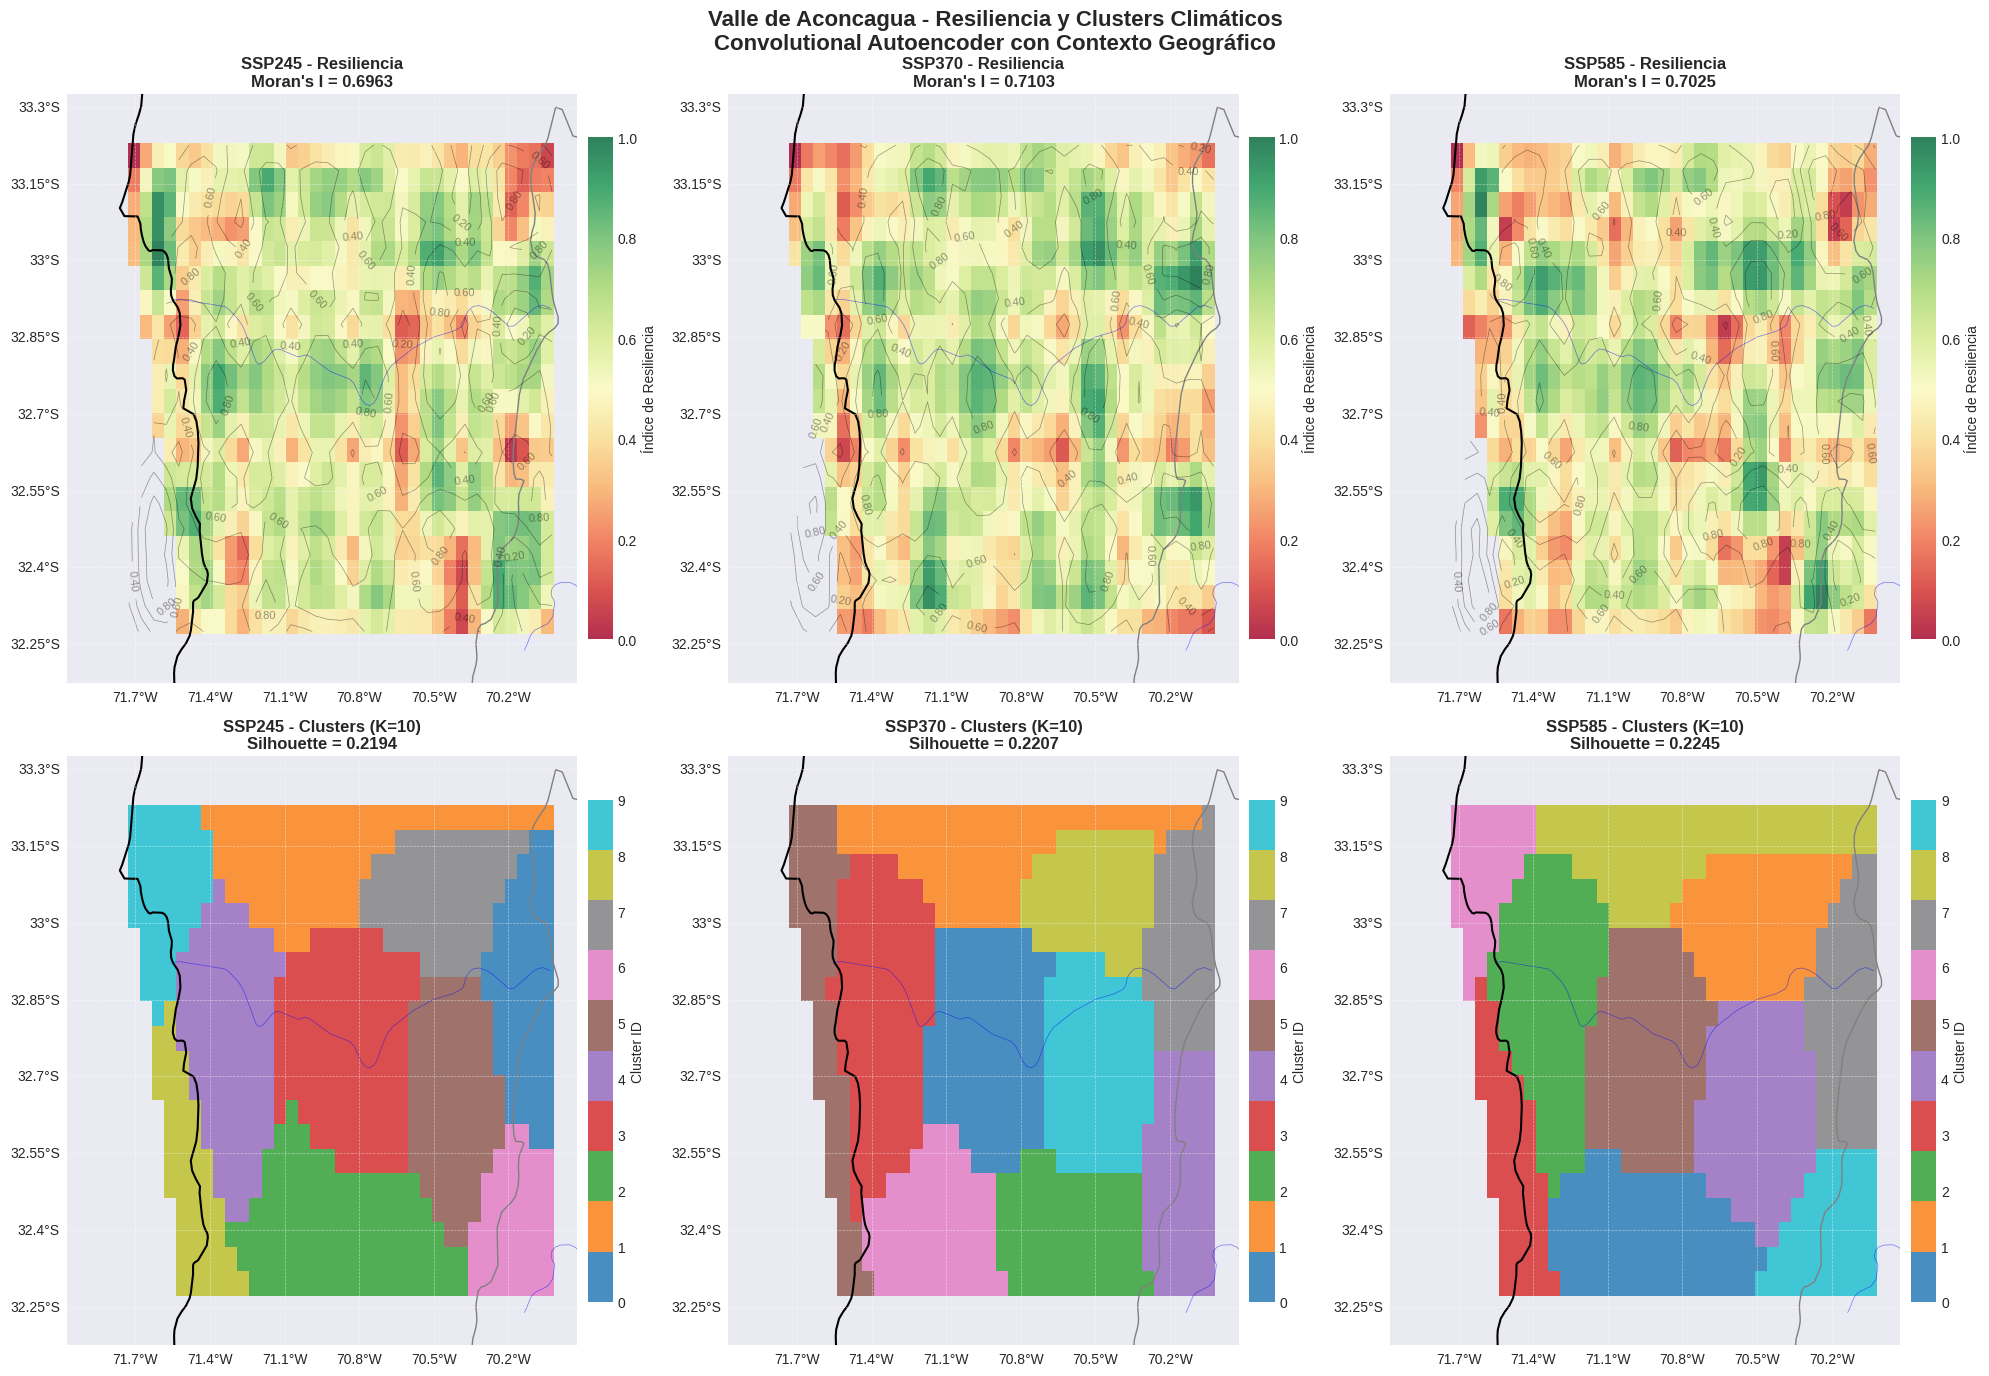

In [84]:
# HEATMAP CON BASEMAP REAL (usando Cartopy si está disponible)
print("="*80)
print("MAPA CON CONTEXTO GEOGRÁFICO")
print("="*80)

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    has_cartopy = True
    print("✅ Cartopy disponible - creando mapa con contexto geográfico")
except ImportError:
    has_cartopy = False
    print("⚠️  Cartopy no disponible - usando mapa sin contexto geográfico")

if has_cartopy:
    # Crear figura con proyección geográfica
    fig = plt.figure(figsize=(20, 14))
    
    # Configurar proyección (PlateCarree para Chile)
    projection = ccrs.PlateCarree()
    
    for idx, scenario in enumerate(SCENARIOS):
        # Fila 1: Resiliencia
        ax1 = fig.add_subplot(2, 3, idx+1, projection=projection)
        
        resilience_2d = resilience_maps[scenario]
        morans = morans_results[scenario]
        
        # GIRAR VERTICALMENTE: flipud invierte de sur→norte a norte→sur
        resilience_2d_flipped = np.flipud(resilience_2d)
        
        # Plotear datos con origin='lower' ahora que los datos están flipados
        # IMPORTANTE: extent también debe invertir lat_min y lat_max
        im1 = ax1.imshow(
            resilience_2d_flipped,
            cmap='RdYlGn',
            vmin=0, vmax=1,
            aspect='auto',
            interpolation='nearest',
            origin='lower',  # Cambiado a 'lower' para que coincida con basemap
            extent=[lon_coords.min(), lon_coords.max(), 
                    lat_coords.max(), lat_coords.min()],  # ← INVERTIDO: lat_max primero
            transform=projection,
            alpha=0.8
        )
        
        # AGREGAR HEATMAP DE DENSIDAD (contornos de resiliencia)
        # Crear meshgrid para contornos
        lon_grid = np.linspace(lon_coords.min(), lon_coords.max(), resilience_2d_flipped.shape[1])
        lat_grid = np.linspace(lat_coords.min(), lat_coords.max(), resilience_2d_flipped.shape[0])
        LON, LAT = np.meshgrid(lon_grid, lat_grid)
        
        # Contornos de resiliencia
        contours = ax1.contour(
            LON, LAT, resilience_2d_flipped,
            levels=5,
            colors='black',
            linewidths=0.5,
            alpha=0.4,
            transform=projection
        )
        ax1.clabel(contours, inline=True, fontsize=8, fmt='%.2f')
        
        # Añadir características geográficas
        ax1.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black')
        ax1.add_feature(cfeature.BORDERS, linewidth=1.0, edgecolor='gray')
        ax1.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)
        ax1.add_feature(cfeature.LAKES, alpha=0.3, facecolor='lightblue')
        
        # Grid lines
        gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl1.top_labels = False
        gl1.right_labels = False
        
        ax1.set_title(f'{scenario.upper()} - Resiliencia\nMoran\'s I = {morans:.4f}', 
                      fontsize=12, fontweight='bold')
        
        # Colorbar
        cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', 
                             pad=0.02, fraction=0.046)
        cbar1.set_label('Índice de Resiliencia', fontsize=10)
        
        # Fila 2: Clusters
        ax2 = fig.add_subplot(2, 3, idx+4, projection=projection)
        
        cluster_2d = cluster_maps[scenario]
        k = clustering_results[scenario]['k']
        silhouette = clustering_results[scenario]['silhouette']
        
        # GIRAR VERTICALMENTE: flipud invierte de sur→norte a norte→sur
        cluster_2d_flipped = np.flipud(cluster_2d)
        
        # Plotear datos con origin='lower' ahora que los datos están flipados
        # IMPORTANTE: extent también debe invertir lat_min y lat_max
        im2 = ax2.imshow(
            cluster_2d_flipped,
            cmap='tab10',
            aspect='auto',
            interpolation='nearest',
            origin='lower',  # Cambiado a 'lower' para que coincida con basemap
            extent=[lon_coords.min(), lon_coords.max(), 
                    lat_coords.max(), lat_coords.min()],  # ← INVERTIDO: lat_max primero
            transform=projection,
            vmin=0, vmax=k-1,
            alpha=0.8
        )
        
        # Características geográficas
        ax2.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black')
        ax2.add_feature(cfeature.BORDERS, linewidth=1.0, edgecolor='gray')
        ax2.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)
        ax2.add_feature(cfeature.LAKES, alpha=0.3, facecolor='lightblue')
        
        # Grid lines
        gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl2.top_labels = False
        gl2.right_labels = False
        
        ax2.set_title(f'{scenario.upper()} - Clusters (K={k})\nSilhouette = {silhouette:.4f}', 
                      fontsize=12, fontweight='bold')
        
        # Colorbar
        cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', 
                             pad=0.02, fraction=0.046)
        cbar2.set_label('Cluster ID', fontsize=10)
        cbar2.set_ticks(range(k))
    
    plt.suptitle('Valle de Aconcagua - Resiliencia y Clusters Climáticos\nConvolutional Autoencoder con Contexto Geográfico', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    # Guardar
    fig_path = PLOTS_DIR / 'georeferenced_with_basemap.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Mapa con basemap guardado en: {fig_path}")
    
    plt.show()

else:
    print("\n💡 Para instalar Cartopy:")
    print("   conda install -c conda-forge cartopy")
    print("   o")
    print("   pip install cartopy")
    print("\n⚠️  Mostrando mapas sin contexto geográfico (ya generados arriba)")

print("\n" + "="*80)

## Guardar Resultados para Análisis Posterior

Exportar resultados de clustering para análisis detallado en notebook 03d.

In [82]:
# Guardar resultados de clustering para análisis en notebook 03d
print("="*80)
print("GUARDANDO RESULTADOS PARA ANÁLISIS POSTERIOR")
print("="*80)

clustering_data = {
    'clustering_results': clustering_results,
    'resilience_by_scenario': resilience_by_scenario,
    'embeddings_by_scenario': embeddings_by_scenario,
    'morans_results': morans_results,
    'scenarios': SCENARIOS,
    'mode': MODE,
    'grid_shape': grid_shape,
    'timestamp': datetime.now().isoformat()
}

output_file = RESULTS_DIR / 'clustering_results_conv.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(clustering_data, f)

print(f"\n✅ Resultados guardados en: {output_file}")
print(f"\n📊 Contenido del archivo:")
print(f"   - clustering_results: Labels, centroides, K, silhouette por escenario")
print(f"   - resilience_by_scenario: Índices de resiliencia")
print(f"   - embeddings_by_scenario: Embeddings concatenados (224D)")
print(f"   - morans_results: Índices de Moran's I")
print(f"\n💡 Este archivo es necesario para ejecutar el notebook 03d_cluster_characterization.ipynb")
print("="*80)

GUARDANDO RESULTADOS PARA ANÁLISIS POSTERIOR

✅ Resultados guardados en: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results/clustering_results_conv.pkl

📊 Contenido del archivo:
   - clustering_results: Labels, centroides, K, silhouette por escenario
   - resilience_by_scenario: Índices de resiliencia
   - embeddings_by_scenario: Embeddings concatenados (224D)
   - morans_results: Índices de Moran's I

💡 Este archivo es necesario para ejecutar el notebook 03d_cluster_characterization.ipynb
